# Education

## Notes 
### Codes For Cost Bases
"Pupil Basis: 1 = Enrollment plus outplaced pupils, 2 = Enrollment in district schools, 4 = Outplaced pupils"
"Pupil Basis: 1 = Enrollment plus outplaced pupils, 2 = Enrollment in district schools, 3 = Total pupils transported"

See SES at 
https://ctdatahaven.org/data-dashboard/connecticut-town-data-viewer/


SocioEconomic Data from National Center for Education Statistics https://nces.ed.gov/programs/edge/Home

In [1]:
from os import path
import glob
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def get_type(x):

    m = re.match(r"(.*)( School District$)", x)
    
    if x.strip().startswith('Regional'):
        return 'Regional'
    elif x.strip().endswith('Academy District'):
        return 'Academy'
    elif x.strip().startswith('Unified'):
        return 'Unified' 
    elif re.search("Charter", x):
        return 'Charter'
    elif x.startswith(('Elm City', 'Odyssey', 'Capital Prep', 'Common Ground')):
        return 'Charter'
    elif m:
        return 'Town'
    else:
        return "Other"

In [3]:
def get_town(x):

    m = re.match(r"(.*)( School District$)", x)
    
    if x.strip().startswith('Regional'):
        return 'Regional'
    elif x.strip().endswith('Academy District'):
        return 'Academy'
    elif x.strip().startswith('Unified'):
        return 'Unified' 
    elif re.search("Charter", x):
        return 'Charter'
    elif x.startswith(('Elm City', 'Odyssey', 'Capital Prep', 'Common Ground')):
        return 'Charter'
    elif m:
        return m.group(1).strip()
    else:
        return "Other"

## Import data

### Inflation
Use the December / Q4 numbers because 
- they are halfway through the school year
- the year column aligns with the starting year of the school year

In [4]:
ipd = pd.read_csv('/Users/joel/Desktop/Granby Benchmarking/price_index_ipd_clean.csv')
ipd = ipd[ipd['Quarter'] == 'Q4'].drop(columns=['Quarter'])
ipd.columns = [c.strip() for c in ipd.columns]
ipd['School Year'] = ipd['Year'].astype('string')
ipd.drop(columns=['Year'], inplace=True)
ipd['IPD'] = ipd['IPD']/100

pce = pd.read_csv('/Users/joel/Desktop/Granby Benchmarking/price_index_pce_clean.csv')[['Year', 'Month', 'PCE']]
pce = pce[pce['Month'] == 'DEC'].drop(columns=['Month'])
pce.columns = [c.strip() for c in pce.columns]
pce['School Year'] = pce['Year'].astype('string')
pce.drop(columns=['Year'], inplace=True)
pce['PCE'] = pce['PCE']/100

### Staffing Levels

In [5]:
ed_dir = '/Users/joel/Desktop/Granby Benchmarking/education/FTES*'
flist = sorted(glob.glob(ed_dir))
dfs = []
for f in flist:
    dd = pd.read_csv(f, header=0, nrows=1)
    yr = dd.columns[0][-8:]
    df = pd.read_csv(f, skiprows=2)
    df['Year'] = yr.strip()
    dfs.append(df)

staffing = pd.concat(dfs)
staffing['Town'] = staffing['District'].apply(lambda x: get_town(x))
staffing['Type'] = staffing['District'].apply(lambda x: get_type(x))
del dfs

In [6]:
staffing.head()

,District,Assignment Category,Educator Type,FTE Count,Year,Town,Type
0,Achievement First Bridgeport Academy District,Administrators Coordinators and Department Ch...,Certified,10.0,2024-25,Academy,Academy
1,Achievement First Bridgeport Academy District,Counselors Social Workers and School Psychol...,Certified,1.0,2024-25,Academy,Academy
2,Achievement First Bridgeport Academy District,General Education - Teachers and Instructors,Certified,41.0,2024-25,Academy,Academy
3,Achievement First Bridgeport Academy District,General Education - Paraprofessional Instructi...,Non-Certified,17.6,2024-25,Academy,Academy
4,Achievement First Bridgeport Academy District,Instructional Specialists Who Support Teachers,Certified,3.0,2024-25,Academy,Academy


### Teacher attrition

In [7]:
# This contains only 
# - district total ('school/program')
# - classroom teachers ('staff type')
attrition = pd.read_excel('/Users/joel/Desktop/Granby Benchmarking/education/Educator Attrition.xlsx')\
              .rename(columns={'School Year':'Year', 'Student Count*': 'Student Count'})

attrition['Town'] = attrition['District'].apply(lambda x: get_town(x))
attrition['Type'] = attrition['District'].apply(lambda x: get_type(x))
attrition['District Code'] = attrition['District Code'].astype('string').str.zfill(7).str.slice(0,3)
attrition['Code'] = attrition['District Code'].astype('int')
attrition['Retained'] = attrition['Rate'].where(attrition['Turnover Description'].str.startswith('Stayed'), 0)
attrition['Elsewhere'] = attrition['Rate'].where(attrition['Turnover Description'].str.startswith('Left the district, stayed in the classroom'), 0)

attrition.sort_values(by=['Code', 'Year'], inplace=True)

/Users/joel/opt/anaconda3/envs/base312/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [8]:
attrition.columns

Index(['Year', 'District', 'School/Program', 'Low Grade', 'High Grade',
       'Turnover (Yes/No)', 'Turnover Description', 'Count', 'Total', 'Rate',
       'Student Count', 'Staff Type', 'District Code', 'SchoolCode',
       'Organization Type', 'Alliance', 'CommishNetwork', 'Focus',
       'Opportunity', 'Priority', 'Turnaround', 'Town', 'Type', 'Code',
       'Retained', 'Elsewhere'],
      dtype='object')

In [9]:
attrition[['District Code', 'District', 'Organization Type', 'Year', 'Turnover Description',
           'Count', 'Retained', 'Elsewhere', 'Rate', 'Student Count']].head(1500).tail(15)

,District Code,District,Organization Type,Year,Turnover Description,Count,Retained,Elsewhere,Rate,Student Count
1779,056,Granby School District,Public School Districts,2021-22,"Left the district, stayed in the classroom",5,0.000000,0.034247,0.034247,1765
1780,056,Granby School District,Public School Districts,2021-22,"Left the district, left the classroom",0,0.000000,0.000000,0.000000,1765
1781,056,Granby School District,Public School Districts,2021-22,Left CT public schools,10,0.000000,0.000000,0.068493,1765
1782,056,Granby School District,Public School Districts,2021-22,"Stayed in the district, stayed in the classroom",131,0.897260,0.000000,0.897260,1765
1797,056,Granby School District,Public School Districts,2021-22,"Stayed in the district, left the classroom",0,0.000000,0.000000,0.000000,1765
1774,056,Granby School District,Public School Districts,2022-23,"Left the district, left the classroom",1,0.000000,0.000000,0.006757,1738
1778,056,Granby School District,Public School Districts,2022-23,"Left the district, stayed in the classroom",7,0.000000,0.047297,0.047297,1738
1789,056,Granby School District,Public School Districts,2022-23,"Stayed in the district, left the classroom",5,0.033784,0.000000,0.033784,1738
1798,056,Granby School District,Public School Districts,2022-23,Left CT public schools,14,0.000000,0.000000,0.094595,1738
1799,056,Granby School District,Public School Districts,2022-23,"Stayed in the district, stayed in the classroom",121,0.817568,0.000000,0.817568,1738


#### Usable columns for teacher attrition

Dataframe **retention**

In [10]:
retention = attrition.groupby(['Code', 'District Code', 'District', 'Year'])\
         .agg({'Count': 'sum', 'Retained': 'sum', 'Elsewhere': 'sum', 'Student Count':'max'})\
        .reset_index()\
        .rename(columns={'Count': 'Classroom Teachers', 'Retained': 'Retention Rate', 'Elsewhere': 'Redistrict Rate'})

retention['District'] = retention['District'].str.strip()
retention['Year'] = retention['Year'].str.strip()
retention.head()

,Code,District Code,District,Year,Classroom Teachers,Retention Rate,Redistrict Rate,Student Count
0,1,001,Andover School District,2018-19,22,0.863636,0.090909,191
1,1,001,Andover School District,2019-20,21,1.000000,0.000000,195
2,1,001,Andover School District,2020-21,22,0.863636,0.000000,174
3,1,001,Andover School District,2021-22,22,0.818182,0.045455,192
4,1,001,Andover School District,2022-23,21,1.000000,0.000000,197


### Accountability Index
Wide-ranging across academic, post-school preparedness, and so on.

I have two sources (not reconciled). 

#### The district level accountability file
This one has reasonably named columns for the success indicators.

In [11]:
# raw numbers
#pd.read_excel('/Users/joel/Desktop/Granby Benchmarking/education/dd7582.xlsx')

# % of points
accountability = pd.read_excel('/Users/joel/Desktop/Granby Benchmarking/education/dd7070.xlsx')
newcols = [c.replace(" (% of points earned)", "").strip() for c in accountability.columns]
newcols = [c.replace(" - All Students", "").strip() for c in newcols]
accountability.columns = newcols
accountability['Town'] = accountability['District'].apply(lambda x: get_town(x))
accountability['Type'] = accountability['District'].apply(lambda x: get_type(x))
accountability['Granby'] = accountability['Town'].where(accountability['Town'] == 'Granby', 'Other')

/Users/joel/opt/anaconda3/envs/base312/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [12]:
accountability.Year.value_counts().sort_index()

Year
2014-15    189
2015-16    192
2016-17    192
2017-18    192
2018-19    192
2021-22    190
2022-23    190
2023-24    190
2024-25    189
Name: count, dtype: int64

In [13]:
accountability.columns

Index(['Year', 'AccountabilityIndex', 'District', 'School', 'ELA PI',
       'ELA PI - High Needs', 'Math PI', 'Math PI - High Needs', 'Science PI',
       'Science PI - High Needs', 'ELA Growth', 'ELA Growth - High Needs',
       'Math Growth', 'Math Growth - High Needs',
       'Progress Toward English Proficiency - Literacy',
       'Progress Toward English Proficiency - Oral', 'Chronic Absenteeism',
       'Chronic Absenteeism - High Needs', 'CCR - Taking Courses',
       'CCR - Passing Exams', 'On-track to HS Graduation', '4-yr Graduation',
       '6-yr Graduation - High Needs', 'Postsecondary Entrance',
       'Physical Fitness', 'Arts Access', 'Town', 'Type', 'Granby'],
      dtype='object')

#### The school-level accountability file
This file contains results at both the school and district level. It has useful columns that may be used to identify the type of school, for example charter schools, that may be used to filter results.

In [14]:
acctfiles = '/Users/joel/Desktop/Granby Benchmarking/education/nextgenacct*.csv'
flist = sorted(glob.glob(acctfiles))

dfs = []
for f in flist:
    dd = pd.read_csv(f, header=0, nrows=1, encoding='cp1252')
    yr = dd.columns[0][-8:]
    _df = pd.read_csv(f, skiprows=2, header=0, encoding='cp1252')
    _df['Year'] = yr.strip()
    dfs.append(_df)

acct = pd.concat(dfs)

acct['District Code'] = acct['ReportingDistrictCode'].apply(lambda x: re.search(r'.*"(\d+)"',x).group(1))
acct['School Code'] = acct['SchoolCode'].apply(lambda x: re.search(r'.*"(\d+)"',x).group(1))
acct['Code'] = acct['District Code'].str.slice(0,3).astype('int')
acct['LowGrade'] = acct['SchoolLowGrade'].str.replace('PK', '0').str.replace('K', '0').str.replace('District', '-1').astype('int')
acct['HighGrade'] = acct['SchoolHighGrade'].str.replace('PK', '0').str.replace('K', '0').str.replace('District', '-1').astype('int')

acct.drop(columns=['ReportingDistrictCode', 'SchoolCode'], inplace=True)
acct.rename(columns={'RptngDistrictName': 'District'}, inplace=True)
del dfs

In [15]:
acct.Category.value_counts()

Category
SchoolTot      9169
DistrictTot    1804
StateTot          9
Name: count, dtype: int64

In [16]:
acct.schoolyear.value_counts().sort_index()

schoolyear
2014-15    1246
2015-16    1246
2016-17    1241
2017-18    1230
2018-19    1222
2021-22    1202
2022-23    1202
2023-24    1199
2024-25    1194
Name: count, dtype: int64

## Make "Type of School" lookup
Useful for finding peer groups - public school districts, K-12

#### Pre-existing Socio-economic groups

In [17]:
# this is a good place to read in the "District Reference Group"
# see separate workbook
drg = pd.read_csv('/Users/joel/Desktop/Granby Benchmarking/education/DRG.csv')

#### Type of school from accountability index data and 'resource group' from state

In [18]:
org_types = acct[acct.SchoolOrgType != 'District'][['District', 'Code', 'SchoolOrgType']]\
            .value_counts().reset_index()[['District', 'Code', 'SchoolOrgType']].value_counts().reset_index().sort_values(by='Code')

grade_types = acct[acct.SchoolOrgType != 'District'].groupby(['District', 'Code'])\
              .agg({'LowGrade':'min', 'HighGrade':'max'}).reset_index().sort_values(by='Code')

org_types = org_types.merge(grade_types, on=['District', 'Code'], how='left')\
                     .merge(drg, on='Code', how='left').drop(columns=['count'])


In [19]:
org_types[~org_types.DRG.isnull()]['SchoolOrgType'].value_counts()

SchoolOrgType
Public Schools                                149
Regional Schools                               17
Endowed and Incorporated Academies Schools      3
Name: count, dtype: int64

In [20]:
school_types = attrition.groupby(['Code', 'District Code', 'District'])[['Low Grade', 'High Grade', 'Organization Type']].max().reset_index()\
                        .merge(drg, on='Code', how='left')

In [21]:
school_types['Organization Type'].value_counts()

Organization Type
Public School Districts                         149
Public Charter School Districts                  22
Regional School Districts                        17
Endowed and Incorporated Academies Districts      3
Name: count, dtype: int64

In [22]:
school_types['DRG'].value_counts()

DRG
E    35
C    30
D    24
B    21
G    17
F    17
H     9
A     9
I     7
Name: count, dtype: int64

### Updated Socioeconomic Groups

In [23]:
jsg = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/new_district_groups.parquet')

In [24]:
school_types = school_types.merge(jsg, on='District', how='left')
school_types[school_types['Organization Type']=='Regional School Districts']

,Code,District Code,District,Low Grade,High Grade,Organization Type,DRG,peer,augmented,elite,urban,pca,affordable,finproj,JSG_ORIG,JSG_AUG,JSG_AFF,JSG_PCA10
149,201,201,Regional School District 01,09,12,Regional School Districts,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,204,204,Regional School District 04,07,12,Regional School Districts,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,205,205,Regional School District 05,07,12,Regional School Districts,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,206,206,Regional School District 06,PreK,12,Regional School Districts,E,1.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,3.0,11.0,7.0
153,207,207,Regional School District 07,07,12,Regional School Districts,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154,208,208,Regional School District 08,07,12,Regional School Districts,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
155,209,209,Regional School District 09,09,12,Regional School Districts,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
156,210,210,Regional School District 10,PreK,12,Regional School Districts,C,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,6.0,5.0,3.0
157,211,211,Regional School District 11,07,12,Regional School Districts,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,212,212,Regional School District 12,PreK,12,Regional School Districts,C,1.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,11.0,7.0


In [25]:
school_types[school_types['District'].str.startswith('Granby')]

,Code,District Code,District,Low Grade,High Grade,Organization Type,DRG,peer,augmented,elite,urban,pca,affordable,finproj,JSG_ORIG,JSG_AUG,JSG_AFF,JSG_PCA10
49,56,056,Granby School District,PreK,12,Public School Districts,B,2.0,2.0,0.0,0.0,2.0,2.0,2.0,6.0,6.0,5.0,3.0


In [26]:
school_types[school_types['DRG'] == 'B']

,Code,District Code,District,Low Grade,High Grade,Organization Type,DRG,peer,augmented,elite,urban,pca,affordable,finproj,JSG_ORIG,JSG_AUG,JSG_AFF,JSG_PCA10
3,4,004,Avon School District,PreK,12,Public School Districts,B,0.0,1.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0
14,18,018,Brookfield School District,PreK,12,Public School Districts,B,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0
20,25,025,Cheshire School District,PreK,12,Public School Districts,B,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
45,51,051,Fairfield School District,PreK,12,Public School Districts,B,0.0,1.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,6.0,6.0
46,52,052,Farmington School District,PreK,12,Public School Districts,B,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
48,54,054,Glastonbury School District,PreK,12,Public School Districts,B,0.0,1.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,5.0
49,56,056,Granby School District,PreK,12,Public School Districts,B,2.0,2.0,0.0,0.0,2.0,2.0,2.0,6.0,6.0,5.0,3.0
50,57,057,Greenwich School District,PreK,12,Public School Districts,B,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,4.0,6.0,6.0
53,60,060,Guilford School District,PreK,12,Public School Districts,B,1.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,0.0,7.0
65,76,076,Madison School District,PreK,12,Public School Districts,B,0.0,1.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0


In [27]:
school_types['JSG_ORIG'].value_counts()

JSG_ORIG
6.0     31
11.0    19
0.0     18
8.0     14
13.0    13
9.0     11
10.0    11
1.0     10
3.0      9
12.0     8
4.0      6
2.0      5
5.0      3
Name: count, dtype: int64

In [28]:
school_types[school_types.JSG_ORIG == 6]

,Code,District Code,District,Low Grade,High Grade,Organization Type,DRG,peer,augmented,elite,urban,pca,affordable,finproj,JSG_ORIG,JSG_AUG,JSG_AFF,JSG_PCA10
0,1,001,Andover School District,PreK,6,Public School Districts,C,1.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,3.0,3.0,5.0
4,5,005,Barkhamsted School District,PreK,6,Public School Districts,C,1.0,0.0,0.0,0.0,1.0,0.0,0.0,6.0,6.0,3.0,3.0
18,23,023,Canton School District,PreK,12,Public School Districts,C,1.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,3.0,7.0,5.0
22,27,027,Clinton School District,PreK,12,Public School Districts,D,1.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,3.0,3.0,5.0
23,28,028,Colchester School District,PreK,12,Public School Districts,D,1.0,0.0,0.0,0.0,1.0,1.0,1.0,6.0,6.0,5.0,3.0
27,32,032,Coventry School District,PreK,12,Public School Districts,E,1.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,3.0,5.0,5.0
28,33,033,Cromwell School District,PreK,12,Public School Districts,D,1.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,1.0,5.0,5.0
35,41,041,East Haddam School District,PreK,12,Public School Districts,E,1.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,3.0,7.0,7.0
36,42,042,East Hampton School District,PreK,12,Public School Districts,D,1.0,0.0,0.0,0.0,1.0,0.0,0.0,6.0,6.0,3.0,3.0
49,56,056,Granby School District,PreK,12,Public School Districts,B,2.0,2.0,0.0,0.0,2.0,2.0,2.0,6.0,6.0,5.0,3.0


## Expenditures by Object 2017-Present
High level (salaries, benefits, purchased services). Not assigned to teaching / non-teaching.

Be aware that tuition is not applied to all students - applies to a different "basis."

#### Includes inflation adjustment

In [29]:
fundingfiles = '/Users/joel/Desktop/Granby Benchmarking/education/EFSDistricLevelbyObjectExport*'
flist = sorted(glob.glob(fundingfiles))
dfs = []
for f in flist:
    dd = pd.read_csv(f, header=0, nrows=1, encoding='cp1252')
    yr = dd.columns[0][-8:]
    _df = pd.read_csv(f, skiprows=10, header=0, encoding='cp1252')
    _df['Year'] = yr.strip()
    _df['Expenditures'] = _df['Expenditures'].str.replace("$", "").str.replace(",","").astype('float')
    _df['PPE'] = _df['PPE'].str.replace("$", "").str.replace(",","").astype('float')
    dfs.append(_df)
object_exp = pd.concat(dfs)

object_exp['Town'] = object_exp['District'].apply(lambda x: get_town(x))
object_exp['Type'] = object_exp['District'].apply(lambda x: get_type(x))
object_exp['District Code'] = object_exp['District Code'].apply(lambda x: re.search(r'.*"(\d+)"',x).group(1))
object_exp['Code'] = object_exp['District Code'].str.slice(0,3).astype('int')
object_exp['School Year'] = object_exp['Year'].str.slice(0,4)

object_exp = object_exp.merge(ipd, on='School Year', how='left').merge(pce, on='School Year', how='left')
object_exp['deflator'] = object_exp['PCE'].where(object_exp['Object'].isin(['Employee Benefits', 'Salaries']), object_exp['IPD'])
object_exp['Real Expenditures'] = np.round(object_exp['Expenditures'] / object_exp['deflator'], 2)
object_exp['Real PPE'] = np.round(object_exp['PPE'] / object_exp['deflator'], 2)

del dfs

In [30]:
object_exp.head(3)

,District,District Code,Object,Expenditures,Pupils,Pupil Basis,PPE,Year,Town,Type,Code,School Year,IPD,PCE,deflator,Real Expenditures,Real PPE
0,Achievement First Bridgeport Academy District,2850013,Salaries,8111945.0,1098,2,7388.0,2023-24,Academy,Academy,285,2023,1.28542,1.2166,1.21660,6667717.41,6072.66
1,Achievement First Bridgeport Academy District,2850013,Employee Benefits,1427869.0,1098,2,1300.0,2023-24,Academy,Academy,285,2023,1.28542,1.2166,1.21660,1173655.27,1068.55
2,Achievement First Bridgeport Academy District,2850013,Purchased Services,5267847.0,1098,2,4798.0,2023-24,Academy,Academy,285,2023,1.28542,1.2166,1.28542,4098152.35,3732.63


In [31]:
pd.DataFrame(object_exp.groupby(['Object', 'Pupil Basis'])[['PPE', 'Real PPE']].mean().sort_values(by='PPE')).style.format(precision=0, thousands=",", decimal=".")

,,PPE,Real PPE
Object,Pupil Basis,,
Other,2,118,104
Property,2,375,327
Other – Includes Tuition,1,617,524
Supplies,2,877,769
Purchased Services,2,"3,172","2,782"
Employee Benefits,2,"3,343","3,055"
Salaries,2,"12,660","11,566"
Total,1,"20,466","17,960"
Tuition,4,"31,259","27,367"


## Expenditures By Function
Functional expenditures are more useful because they describe "what's going on" at the school.

From https://edsight.ct.gov/relatedreports/ReportNotes_PPR.pdf


Instructional Staff and Services
- Expenditures for salaries and employee benefits, purchased services and other program
expenditures.

Instructional Supplies and Equipment
- Expenditures for expendable instructional materials, textbooks, workbooks, and textbook
binding and repairs. Expenditures for equipment, such as computers and VCRs, that is used
for direct instructional use, not for administrative or non-instructional purposes.

Improvement of Instruction and Educational Media Services
- Expenditures for activities primarily for assisting instructional staff in planning, developing, 
and evaluating the process of providing learning experiences for students. These activities
include curriculum development, techniques of instruction, staff training, etc. Also,
expenditures for activities concerned with the use of all teaching and learning resources,
including hardware, and content materials. Includes supervision of educational media
services, school library services, audiovisual services, educational television services,
computer-assisted instruction services, etc.

Student Support Services
- Expenditures for activities designed to improve students’ well-being and educational
experience. These activities include social work, guidance, health, psychological and speech
and hearing services.

Administration and Support Services
- Expenditures for the general administration of the board of education, the superintendent,
and the principals’ offices. Expenditures for other activities, including those associated with
fiscal and business support services, research, planning, evaluation, information, and data
processing, etc.

Plant Operation and Maintenance
- Expenditures for the operation and maintenance of school buildings and property, including
expenditures for utilities and heat.

Transportation
- The reimbursable and non-reimbursable (e.g., expenditures for field trips) transportation
expenditures, including vehicles, supplies, salaries, and fringe benefits. To obtain the
expenditures per pupil, the expenditures were divided by the number of resident students
enrolled in district schools or placed in schools outside the district.

Costs for Students Tuitioned Out
- Expenditures for tuition for resident students educated outside the school district. No per
pupil amount is calculated. Expenditures for secondary students from towns with
elementary school districts were not included in the elementary school districts’
expenditures.

Other
- Expenditures made from local appropriations that support student activities, excluding
funds raised by students and booster groups. These local appropriations support salaries of
coaches, activity supervisors, support services personnel covering student events, band
instruments, uniforms, and facility rentals. Also, expenditures funded by local tax dollars for
providing food to pupils and staff.

Total
- Total of all expenditures above. Expenditures for secondary students from towns with
elementary school districts were not included in the elementary school districts’
expenditures.
Land, Buildings and Debt Servi

## Expenditures by Function 2017-Present
More useful for analysis: broken down into instructional, administrative, student support, etc.

#### Pupil basis
For functional expenditures...  
1 = Enrollment plus outplaced pupils,  
2 = Enrollment in district schools,  
3 = Total pupils transported

In [32]:
fundingfiles = '/Users/joel/Desktop/Granby Benchmarking/education/EFSDistricLevelbyFunction*'
flist = sorted(glob.glob(fundingfiles))
dfs = []
for f in flist:
    dd = pd.read_csv(f, header=0, nrows=1, encoding='cp1252')
    yr = dd.columns[0][-8:]
    _df = pd.read_csv(f, skiprows=9, header=0, encoding='cp1252')
    _df['Year'] = yr.strip()
    _df['Expenditures'] = _df['Expenditures'].str.replace("$", "").str.replace(",","").astype('float')
    _df['PPE'] = _df['PPE'].str.replace("$", "").str.replace(",","").astype('float')
    dfs.append(_df)

function_exp = pd.concat(dfs)
function_exp['Town'] = function_exp['District'].apply(lambda x: get_town(x))
function_exp['Type'] = function_exp['District'].apply(lambda x: get_type(x))
function_exp['District Code'] = function_exp['District Code'].apply(lambda x: re.search(r'.*"(\d+)?"',x).group(1))
function_exp['District Code'] = function_exp['District Code'].str.slice(0,3)
function_exp['Code'] = function_exp['District Code'].str.slice(0,3).astype('int')
del dfs

In [33]:
function_exp.Year.value_counts().sort_index()

Year
2017-18    2364
2018-19    2352
2019-20    2340
2020-21    2328
2021-22    2340
2022-23    2340
2023-24    2340
Name: count, dtype: int64

In [34]:
pd.DataFrame(function_exp.groupby(['Function', 'Pupil Basis'])['PPE'].mean().sort_values()).style.format(precision=0, thousands=",", decimal=".")

,,PPE
Function,Pupil Basis,
Food services,2.000000,25
Minor school construction,2.000000,87
Enterprise operations,2.000000,165
Central and other support services,2.000000,735
Support services - general administration,2.000000,742
Support services - instruction,2.000000,796
Support services - school based administration,2.000000,"1,337"
Student transportation services,3.000000,"1,532"
Support services - students,2.000000,"1,662"


In [35]:
function_exp.head(3)

,District,District Code,Function,Expenditures,Pupils,Pupil Basis,PPE,Year,Town,Type,Code
0,Achievement First Bridgeport Academy District,285,Instruction,9190429.0,1098.0,1.0,8370.0,2023-24,Academy,Academy,285
1,Achievement First Bridgeport Academy District,285,Support services - students,1180418.0,1098.0,2.0,1075.0,2023-24,Academy,Academy,285
2,Achievement First Bridgeport Academy District,285,Support services - instruction,270494.0,1098.0,2.0,246.0,2023-24,Academy,Academy,285


In [36]:
function_exp[(function_exp.District.str.startswith('Gran')) & (function_exp.Function.str.startswith('Student tr'))]\
[['District', 'Year', 'Expenditures', 'Pupils']]

,District,Year,Expenditures,Pupils
799,Granby School District,2023-24,2325183.0,1497.0
799,Granby School District,2022-23,2319397.0,1626.0
799,Granby School District,2021-22,1430656.0,1639.0
787,Granby School District,2020-21,1559556.0,1615.0
787,Granby School District,2019-20,1406542.0,1670.0
787,Granby School District,2018-19,1596955.0,1746.0
787,Granby School District,2017-18,1460446.0,1906.0


### Make district-to-code mapping file

In [37]:
district_code_map = function_exp[['District', 'Code']].drop_duplicates()

### Expenditures by Function 2016 and earlier
There are two separate files. One is per-pupil and the other is total expenditures. They can be combined to infer the number of pupils used for the calculation.

The functional categories are slightly different and may not align with later years. There may be more detail in the early files (such as for Instructional expenses) or in the later files (administration & support services)

#### Individual files

In [38]:
# source: https://portal.ct.gov/sde/fiscal-services/connecticut-public-school-expenditures-report
# originally excel files, had to manually clean up to be able to read as dataframes
fundingfiles = '/Users/joel/Desktop/Granby Benchmarking/education/FUNPERP_excel*.csv'
flist = sorted(glob.glob(fundingfiles))
dfs = []
for f in flist:
    _df = pd.read_csv(f, encoding='cp1252')
    dfs.append(_df)

early_pp = pd.concat(dfs)

early_pp = early_pp.merge(district_code_map, on='Code', how='left')
early_pp['District Code'] = early_pp['Code'].astype(str).str.zfill(3)

early_pp.head(2)

,Code,Name,Instruction,Support - Instruction,School Admin,General Admin,Plant,Debt Service,Special Ed Transport,Regular Transport,Transportation,School Year,District,District Code
0,1,ANDOVER,12268,1607,1181,1330,5132,519,23693,670,767,2016-17,Andover School District,001
1,2,ANSONIA,9483,530,781,814,1124,1043,8279,402,895,2016-17,Ansonia School District,002


In [39]:
early_pp[early_pp.District.isnull()].shape

(0, 14)

In [40]:
early_pp.rename(columns={'Instruction': 'Instruction',
             'Support - Instruction': 'Support services - instruction',
             'School Admin': 'Support services - school based administration',
             'General Admin': 'Support services - general administration',
             'Plant': 'Operation and maintenance of plant',
             'Transportation': 'Student transportation services',
             'School Year': 'Year'}, inplace=True)

early_pp['Name'] = early_pp['Name'].str.strip().str.replace('"','').str.title()

early_pp = pd.melt(early_pp, id_vars=['District Code', 'Code', 'Name', 'District', 'Year'], var_name='Function', value_name='PPE')\
             .sort_values(by=['District Code', 'Code', 'Name', 'District', 'Function']).drop(columns=['Name'])

early_pp['PPE'] = early_pp['PPE'].astype(str).str.replace(",","").astype('float')

early_pp['Town'] = early_pp['District'].apply(lambda x: get_town(x))
early_pp['Type'] = early_pp['District'].apply(lambda x: get_type(x))

del dfs

In [41]:
early_pp['Year'].value_counts().sort_index()

Year
2009-10    1494
2010-11    1494
2011-12    1494
2012-13    1494
2013-14    1422
2014-15    1494
2015-16    1494
2016-17    1494
Name: count, dtype: int64

In [42]:
early_pp.head(5)

,District Code,Code,District,Year,Function,PPE,Town,Type
6600,001,1,Andover School District,2016-17,Debt Service,519.0,Andover,Town
6878,001,1,Andover School District,2015-16,Debt Service,483.0,Andover,Town
7044,001,1,Andover School District,2014-15,Debt Service,441.0,Andover,Town
7210,001,1,Andover School District,2013-14,Debt Service,420.0,Andover,Town
7368,001,1,Andover School District,2012-13,Debt Service,423.0,Andover,Town


In [43]:
pd.DataFrame(early_pp.groupby('Function')['PPE'].mean().sort_values()).style.format(precision=0, thousands=",", decimal=".")

,PPE
Function,
Regular Transport,674
Support services - general administration,869
Student transportation services,881
Support services - school based administration,939
Debt Service,"1,286"
Support services - instruction,"1,532"
Operation and maintenance of plant,"1,674"
Instruction,"9,658"
Special Ed Transport,"12,815"


#### From trend reports
These have slightly different categories that the individual files, but also fewer years.

The trend reports separate total expenditures and per-pupil expenditures; these are merged and used to estimate the pupil count.

In [44]:
# might need to sum types of instruction
# might need to 
function_map = {'Instructional Staff and Services': 'Instruction',
                'Instructional Supplies and Equipment': 'Instruction',
                'Instruction and Educational Media Services': 'Instruction',
                'Student Support Services': 'Support services - students',
                'Total Expenditures': 'Total',
                'Transportation': 'Student transportation services',
                'Plant Operation and Maintenance': 'Operation and maintenance of plant'}

In [45]:
# https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district/per-pupil-expenditures-2016-17-and-earlier?language=en_US
# https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district/total-annual-expenditures-by-type-2016-17-and-earlier?language=en_US

_exp = pd.read_csv('/Users/joel/Desktop/Granby Benchmarking/education/FunctionalfiscalResources.csv')
_exp.columns = [c.strip() for c in _exp.columns]
_exp['District'] = _exp['District'].str.strip()
_exp['Function'] = _exp['Function'].str.strip()
early_expenditures = pd.melt(_exp, id_vars=['District', 'Function'], var_name='Year', value_name='Expenditures')

In [46]:
_exp = pd.read_csv('/Users/joel/Desktop/Granby Benchmarking/education/FunctionalperPupilExpeditures.csv')

_exp.columns = [c.strip() for c in _exp.columns]
_exp['District'] = _exp['District'].str.strip()
_exp['Function'] = _exp['Function'].str.strip()
early_ppexpenditures = pd.melt(_exp, id_vars=['District', 'Function'], var_name='Year', value_name='PPE')

In [47]:
# combine

early_expenditures = early_expenditures.merge(early_ppexpenditures, how='left', on=['District', 'Function', 'Year'])\
                                       .merge(district_code_map, on='District', how='left')

early_expenditures['District Code'] = early_expenditures['Code'].astype(str).str.zfill(3)
early_expenditures['Town'] = early_expenditures['District'].apply(lambda x: get_town(x))
early_expenditures['Type'] = early_expenditures['District'].apply(lambda x: get_type(x))

early_expenditures['Pupils'] = np.round(early_expenditures['Expenditures'] / early_expenditures['PPE'],0)

# replace original function with functions like later files
early_expenditures ['Early Function'] = early_expenditures ['Function']
early_expenditures ['Function'] = early_expenditures['Function'].map(function_map)
early_expenditures ['Function'] = early_expenditures['Function'].where(~early_expenditures['Function'].isnull(),early_expenditures['Early Function'])

# because later files have fewer categories for Instruction, need to combine those rows
eexp = early_expenditures.groupby(['District Code', 'Code', 'District', 'Town', 'Type', 'Function', 'Year']).agg({'Expenditures':'sum', 'Pupils':'mean'})\
                         .reset_index().sort_values(by=['Code', 'District', 'Year', 'Function'])

# fill in PPE for operation of plant using the function with the most pupils
inst_pupils = eexp[eexp['Function'] == 'Instruction'].groupby(['Code', 'District', 'Year'])['Pupils'].max().reset_index()\
             .rename(columns={'Pupils':'pupils_inst'})
admin_pupils = eexp[eexp['Function'].str.startswith('Administration and')].groupby(['Code', 'District', 'Year'])['Pupils'].max().reset_index()\
             .rename(columns={'Pupils':'pupils_admin'})
eexp = eexp.merge(admin_pupils, on=['Code', 'District', 'Year'], how='left')
eexp['Pupils'] = eexp['Pupils'].where(~eexp['Function'].str.startswith('Operation and maintenance'), eexp['pupils_admin'])

eexp['PPE'] = round(eexp['Expenditures']/eexp['Pupils'], 2)
eexp.drop(columns=['pupils_admin'], inplace=True)

In [48]:
eexp.Year.value_counts()

Year
2012-13    1520
2013-14    1520
2014-15    1520
2015-16    1520
2016-17    1520
Name: count, dtype: int64

In [49]:
eexp.head(5)

,District Code,Code,District,Town,Type,Function,Year,Expenditures,Pupils,PPE
0,001,1,Andover School District,Andover,Town,Administration and Support Services,2012-13,609305.0,314.000000,1940.46
1,001,1,Andover School District,Andover,Town,Instruction,2012-13,2791330.0,314.333333,8880.16
2,001,1,Andover School District,Andover,Town,Operation and maintenance of plant,2012-13,439659.0,314.000000,1400.19
3,001,1,Andover School District,Andover,Town,Other,2012-13,0.0,NaN,NaN
4,001,1,Andover School District,Andover,Town,Student transportation services,2012-13,253379.0,689.000000,367.75


In [50]:
pd.DataFrame(eexp.groupby('Function')[['Expenditures','PPE']].mean().sort_values(by='PPE')).style.format(precision=0, thousands=",", decimal=".")

,Expenditures,PPE
Function,,
Other,"521,483",273
Student transportation services,"2,469,671",880
Support services - students,"2,757,872","1,143"
Operation and maintenance of plant,"4,220,840","1,745"
Administration and Support Services,"4,663,905","2,132"
Instruction,"27,110,798","10,384"
Total,"44,185,244","16,804"
Students Tuitioned Out,"2,440,676",nan


#### Reconciliation
The individual excel files only report per-pupil expenditures, whereas the trend reports include total expenditures. Thus the trend reports are more useful for analysis 

In [51]:
checkdf = eexp.merge(early_pp[['District', 'Function', 'Year', 'PPE']].rename(columns={'PPE': 'PPE_check'}),
                   on=['District', 'Function', 'Year'], how='left')
checkdf['percdiff'] = (checkdf['PPE'] - checkdf['PPE_check'])/checkdf['PPE']

In [52]:
checkdf.groupby('Function')['percdiff'].describe()

,count,mean,std,min,25%,50%,75%,max
Function,,,,,,,,
Administration and Support Services,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Instruction,818.0,0.053937,0.035721,-0.113107,0.028572,0.047192,0.075961,0.239164
Operation and maintenance of plant,818.0,0.005135,0.071978,-0.740333,-0.000188,0.000009,0.000246,0.627829
Other,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Student transportation services,818.0,-0.109763,0.323268,-1.415839,-0.047704,-0.020516,-0.007700,1.000000
Students Tuitioned Out,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Support services - students,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
pd.DataFrame(early_pp.groupby('Function')['PPE'].mean().sort_values()).style.format(precision=0, thousands=",", decimal=".")

,PPE
Function,
Regular Transport,674
Support services - general administration,869
Student transportation services,881
Support services - school based administration,939
Debt Service,"1,286"
Support services - instruction,"1,532"
Operation and maintenance of plant,"1,674"
Instruction,"9,658"
Special Ed Transport,"12,815"


In [54]:
# Get Pupil Count to infer Expenditures
early_pp = early_pp.merge(admin_pupils, on=['Code', 'District', 'Year'], how='left')\
                   .merge(inst_pupils, on=['Code', 'District', 'Year'], how='left')

early_pp['Pupils'] = early_pp['pupils_inst'].where(early_pp['Function'].isin(['Support services - instruction', 'Instruction']),np.nan)
early_pp['Pupils'] = early_pp['Pupils'].where(~early_pp['Function'].isin(['Student transportation services',
                                                                           'Support services - general administration',
                                                                           'Support services - school based administration',
                                                                           'Operation and maintenance of plant']),early_pp['pupils_admin'])
early_pp['Expenditures'] = early_pp['Pupils'] * early_pp['PPE']
early_pp.drop(columns=['pupils_admin', 'pupils_inst'], inplace=True)

In [55]:
early_pp.head(25).tail(10)

,District Code,Code,District,Year,Function,PPE,Town,Type,Pupils,Expenditures
15,001,1,Andover School District,2009-10,Instruction,7883.0,Andover,Town,NaN,NaN
16,001,1,Andover School District,2016-17,Operation and maintenance of plant,5132.0,Andover,Town,225.0,1154700.0
17,001,1,Andover School District,2015-16,Operation and maintenance of plant,1831.0,Andover,Town,250.0,457750.0
18,001,1,Andover School District,2014-15,Operation and maintenance of plant,1772.0,Andover,Town,275.0,487300.0
19,001,1,Andover School District,2013-14,Operation and maintenance of plant,1519.0,Andover,Town,298.0,452662.0
20,001,1,Andover School District,2012-13,Operation and maintenance of plant,1358.0,Andover,Town,314.0,426412.0
21,001,1,Andover School District,2011-12,Operation and maintenance of plant,1358.0,Andover,Town,NaN,NaN
22,001,1,Andover School District,2010-11,Operation and maintenance of plant,1360.0,Andover,Town,NaN,NaN
23,001,1,Andover School District,2009-10,Operation and maintenance of plant,1179.0,Andover,Town,NaN,NaN
24,001,1,Andover School District,2016-17,Regular Transport,670.0,Andover,Town,NaN,NaN


In [56]:
checkdf = eexp.merge(early_pp[['District', 'Function', 'Year', 'Expenditures']].rename(columns={'Expenditures': 'check'}),
                   on=['District', 'Function', 'Year'], how='left')
checkdf['percdiff'] = (checkdf['Expenditures'] - checkdf['check'])/checkdf['Expenditures']
checkdf.groupby('Function')['percdiff'].describe()

,count,mean,std,min,25%,50%,75%,max
Function,,,,,,,,
Administration and Support Services,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Instruction,818.0,0.053937,0.035721,-0.113106,0.028572,0.047192,0.075961,0.239164
Operation and maintenance of plant,818.0,0.005135,0.071978,-0.740329,-0.000189,0.000007,0.000244,0.627829
Other,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Student transportation services,818.0,0.108505,0.157897,-0.245798,0.022115,0.067142,0.160308,1.000000
Students Tuitioned Out,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Support services - students,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Concatenate Functional Expenditures: 2012-Present
### Inflation adjustment

In [57]:
function_exp = pd.concat([function_exp,
                    early_pp[(early_pp['Function'].isin(['Support services - instruction',
                                                         'Support services - general administration',
                                                         'Support services - school based administration']))
                            & (early_pp['Year'] >= '2012-13')],
                    eexp[eexp['Function'].isin(['Administration and Support Services',
                                                'Instruction',
                                                'Operation and maintenance of plant',
                                                'Student transportation services'])]
                         ]).sort_values(by=['Code', 'District', 'Year', 'Function'])

function_exp['School Year'] = function_exp['Year'].str.slice(0,4)
function_exp.shape

(22670, 12)

In [58]:
function_exp = function_exp.merge(ipd, on='School Year', how='left').merge(pce, on='School Year', how='left')

function_exp['deflator'] = object_exp['IPD'].where(function_exp['Function'].isin(['Operation and maintenance of plant',
                                                                                  'Food services',
                                                                                  'Student transportation services',
                                                                                  'Enterprise operations',
                                                                                  'Minor school construction',
                                                                                 ]), function_exp['PCE'])

function_exp['Real Expenditures'] = np.round(function_exp['Expenditures'] / function_exp['deflator'], 2)
function_exp['Real PPE'] = np.round(function_exp['PPE'] / function_exp['deflator'], 2)
function_exp.shape

(22670, 17)

In [59]:
function_exp['School Year'].value_counts()

School Year
2017    2364
2018    2352
2019    2340
2021    2340
2022    2340
2023    2340
2020    2328
2012    1258
2014    1258
2015    1258
2016    1258
2013    1234
Name: count, dtype: int64

In [60]:
function_exp.head(350).tail(5)

,District,District Code,Function,Expenditures,Pupils,Pupil Basis,PPE,Year,Town,Type,Code,School Year,IPD,PCE,deflator,Real Expenditures,Real PPE
345,Ashford School District,003,Central and other support services,438402.0,354.0,2.0,1238.0,2023-24,Ashford,Town,3,2023,1.28542,1.2166,1.21660,360350.16,1017.59
346,Ashford School District,003,Enterprise operations,0.0,354.0,2.0,0.0,2023-24,Ashford,Town,3,2023,1.28542,1.2166,1.28542,0.00,0.00
347,Ashford School District,003,Food services,54986.0,354.0,2.0,155.0,2023-24,Ashford,Town,3,2023,1.28542,1.2166,1.28542,42776.68,120.58
348,Ashford School District,003,Instruction,5541529.0,357.0,1.0,15522.0,2023-24,Ashford,Town,3,2023,1.28542,1.2166,1.21660,4554930.96,12758.51
349,Ashford School District,003,Minor school construction,NaN,NaN,NaN,NaN,2023-24,Ashford,Town,3,2023,1.28542,1.2166,1.28542,NaN,NaN


In [61]:
pd.DataFrame(function_exp.groupby(['Function'])['Expenditures'].count()).style.format(precision=2, thousands=",", decimal=".")

,Expenditures
Function,
Administration and Support Services,950
Central and other support services,"1,367"
Enterprise operations,"1,367"
Food services,"1,367"
Instruction,"2,317"
Minor school construction,393
Operation and maintenance of plant,"2,317"
Student transportation services,"2,317"
Support services - general administration,"2,185"


## Calculate Expenditure Growth By Function
Using earliest reported data (2017) as the base. If it is $0 then use 2018. If neither of those bases are positive, then the growth rates are set to missing.

In [62]:
# aggregate administration to match earlier years
function_agg = {'Support services - general administration': 'Administration and Support Services',
                'Support services - school based administration': 'Administration and Support Services',
                'Central and other support services': 'Administration and Support Services'}

fexp = function_exp.merge(school_types, on='District', how='left')

fexp['Late Function'] = fexp['Function']
fexp['Function'] = fexp['Function'].map(function_agg)
fexp['Function'] = fexp['Function'].where(~fexp['Function'].isnull(),fexp['Late Function'])

fexp = fexp.groupby(['District', 'Town', 'Type', 'Organization Type', 'Function', 'Year'])\
            .agg({'Expenditures':'sum', 'Real Expenditures':'sum', 'Pupils':'mean'}).reset_index()

fexp['PPE'] = round(fexp['Expenditures']/fexp['Pupils'], 2)
fexp['Real PPE'] = round(fexp['Real Expenditures']/fexp['Pupils'], 2)
fexp.shape

(17702, 11)

In [63]:
fexp[fexp.Function == 'Instruction'].head()

,District,Town,Type,Organization Type,Function,Year,Expenditures,Real Expenditures,Pupils,PPE,Real PPE
26,Achievement First Bridgeport Academy District,Academy,Academy,Public Charter School Districts,Instruction,2012-13,4871181.0,0.0,702.000000,6939.00,0.0
27,Achievement First Bridgeport Academy District,Academy,Academy,Public Charter School Districts,Instruction,2013-14,6427400.0,0.0,835.000000,7697.49,0.0
28,Achievement First Bridgeport Academy District,Academy,Academy,Public Charter School Districts,Instruction,2014-15,7208665.0,0.0,976.666667,7380.89,0.0
29,Achievement First Bridgeport Academy District,Academy,Academy,Public Charter School Districts,Instruction,2015-16,5903546.0,0.0,1016.000000,5810.58,0.0
30,Achievement First Bridgeport Academy District,Academy,Academy,Public Charter School Districts,Instruction,2016-17,7179438.0,0.0,1044.000000,6876.86,0.0


In [64]:
fexp.Year.value_counts()

Year
2017-18    1880
2018-19    1880
2019-20    1880
2020-21    1870
2021-22    1870
2022-23    1870
2023-24    1870
2012-13     918
2014-15     918
2015-16     918
2016-17     918
2013-14     910
Name: count, dtype: int64

In [65]:
fexp.columns

Index(['District', 'Town', 'Type', 'Organization Type', 'Function', 'Year',
       'Expenditures', 'Real Expenditures', 'Pupils', 'PPE', 'Real PPE'],
      dtype='object')

In [66]:
fexp[fexp['Function'].isin(['Instruction'])][['District', 'Function', 'Year', 'Expenditures', 'Real Expenditures', 'PPE', 'Pupils']].head(235).tail(10)

,District,Function,Year,Expenditures,Real Expenditures,PPE,Pupils
1720,Bristol School District,Instruction,2021-22,93906084.0,83701976.09,11627.80,8076.000000
1721,Bristol School District,Instruction,2022-23,113666527.0,96015109.31,14045.04,8093.000000
1722,Bristol School District,Instruction,2023-24,115190536.0,94682340.95,14236.87,8091.000000
1806,Brookfield School District,Instruction,2012-13,25946331.0,27284929.65,9299.76,2790.000000
1807,Brookfield School District,Instruction,2013-14,26960255.0,27963008.48,9758.78,2762.666667
1808,Brookfield School District,Instruction,2014-15,24588642.0,25317794.48,9065.49,2712.333333
1809,Brookfield School District,Instruction,2015-16,25414189.0,26077603.23,9485.27,2679.333333
1810,Brookfield School District,Instruction,2016-17,25952018.0,26195373.02,9744.19,2663.333333
1811,Brookfield School District,Instruction,2017-18,25975887.0,25764361.59,9617.14,2701.000000
1812,Brookfield School District,Instruction,2018-19,26648470.0,25947624.66,9899.13,2692.000000


#### Growth is cumulative vs. 2017

In [67]:
# vs. 2017 or 2018
function_2017 = function_exp[(function_exp['Year'] == '2017-18')].rename(columns={'PPE': 'PPE_2017',
                                                                                  'Expenditures': 'Expenditures_2017',
                                                                                  'Real PPE': 'Real_PPE_2017',
                                                                                  'Real Expenditures': 'Real_Expenditures_2017',
                                                                                  'Pupils': 'Pupils_2017'})

function_2018 = function_exp[(function_exp['Year'] == '2018-19')].rename(columns={'PPE': 'PPE_2018',
                                                                                  'Expenditures': 'Expenditures_2018',
                                                                                  'Real PPE': 'Real_PPE_2018',
                                                                                  'Real Expenditures': 'Real_Expenditures_2018',
                                                                                  'Pupils': 'Pupils_2018'})

function_exp = function_exp.merge(function_2017[['Town', 'District', 'Function', 'Expenditures_2017', 'PPE_2017',
                                                 'Real_Expenditures_2017', 'Real_PPE_2017','Pupils_2017']],
                                  on=['Town', 'District', 'Function'], how='left')\
                           .merge(function_2018[['Town', 'District', 'Function', 'Expenditures_2018', 'PPE_2018',
                                                 'Real_Expenditures_2018', 'Real_PPE_2018','Pupils_2018']],
                                  on=['Town', 'District', 'Function'], how='left')\
                           .merge(school_types, how='left', on='District')

function_exp['Pupils_Base'] = function_exp['Pupils_2017'].where(function_exp['Pupils_2017'] > 0, function_exp['Pupils_2018'])
function_exp['PPE_Base'] = function_exp['PPE_2017'].where(function_exp['PPE_2017'] > 0, function_exp['PPE_2018'])
function_exp['Expenditures_Base'] = function_exp['Expenditures_2017'].where(function_exp['Expenditures_2017'] > 0, function_exp['Expenditures_2018'])

function_exp['Real_PPE_Base'] = function_exp['Real_PPE_2017'].where(function_exp['Real_PPE_2017'] > 0, function_exp['Real_PPE_2018'])
function_exp['Real_Expenditures_Base'] = function_exp['Real_Expenditures_2017'].where(function_exp['Real_Expenditures_2017'] > 0, function_exp['Real_Expenditures_2018'])

function_exp['Pupil_Growth'] = function_exp['Pupils'] / function_exp['Pupils_Base']
function_exp['PPE_Growth'] = function_exp['PPE'] / function_exp['PPE_Base']
function_exp['Expenditures_Growth'] = function_exp['Expenditures'] / function_exp['Expenditures_Base']

function_exp['Real_PPE_Growth'] = function_exp['Real PPE'] / function_exp['Real_PPE_Base']
function_exp['Real_Expenditures_Growth'] = function_exp['Real Expenditures'] / function_exp['Real_Expenditures_Base']

function_exp['PPE_Growth'] = function_exp['PPE_Growth'].where(function_exp['PPE_Base'] > 0, np.nan)
function_exp['Expenditures_Growth'] = function_exp['Expenditures_Growth'].where(function_exp['Expenditures_Base'] > 0, np.nan)
function_exp['Real_PPE_Growth'] = function_exp['Real_PPE_Growth'].where(function_exp['Real_PPE_Base'] > 0, np.nan)
function_exp['Real_Expenditures_Growth'] = function_exp['Real_Expenditures_Growth'].where(function_exp['Real_Expenditures_Base'] > 0, np.nan)

function_exp.sort_values(by=['School Year', 'District'], ascending=True, inplace=True)

#### Mark separate granby series

In [68]:
# make series for Granby overlays on the charts
function_exp['Granby'] = function_exp['Town'].where(function_exp['Town'] == 'Granby', 'Other')
function_exp['Granby_EG'] = function_exp['Expenditures_Growth'].where(function_exp['Town'] == 'Granby', None)
function_exp['Granby_PPEG'] = function_exp['PPE_Growth'].where(function_exp['Town'] == 'Granby', None)
function_exp['Granby_Real_EG'] = function_exp['Real_Expenditures_Growth'].where(function_exp['Town'] == 'Granby', None)
function_exp['Granby_Real_PPEG'] = function_exp['Real_PPE_Growth'].where(function_exp['Town'] == 'Granby', None)

In [69]:
function_exp[~function_exp['Granby_PPEG'].isna()]['Year'].value_counts()

Year
2017-18    11
2018-19    11
2019-20    11
2020-21    11
2021-22    11
2022-23    11
2023-24    11
2012-13     6
2013-14     6
2014-15     6
2015-16     6
2016-17     6
Name: count, dtype: int64

In [70]:
function_exp.sort_values(by=['District', 'Function', 'Year'], ascending=True, inplace=True)
function_exp.reset_index(inplace=True)

In [71]:
function_exp.columns

Index(['index', 'District', 'District Code_x', 'Function', 'Expenditures',
       'Pupils', 'Pupil Basis', 'PPE', 'Year', 'Town', 'Type', 'Code_x',
       'School Year', 'IPD', 'PCE', 'deflator', 'Real Expenditures',
       'Real PPE', 'Expenditures_2017', 'PPE_2017', 'Real_Expenditures_2017',
       'Real_PPE_2017', 'Pupils_2017', 'Expenditures_2018', 'PPE_2018',
       'Real_Expenditures_2018', 'Real_PPE_2018', 'Pupils_2018', 'Code_y',
       'District Code_y', 'Low Grade', 'High Grade', 'Organization Type',
       'DRG', 'peer', 'augmented', 'elite', 'urban', 'pca', 'affordable',
       'finproj', 'JSG_ORIG', 'JSG_AUG', 'JSG_AFF', 'JSG_PCA10', 'Pupils_Base',
       'PPE_Base', 'Expenditures_Base', 'Real_PPE_Base',
       'Real_Expenditures_Base', 'Pupil_Growth', 'PPE_Growth',
       'Expenditures_Growth', 'Real_PPE_Growth', 'Real_Expenditures_Growth',
       'Granby', 'Granby_EG', 'Granby_PPEG', 'Granby_Real_EG',
       'Granby_Real_PPEG'],
      dtype='object')

**Note** that if a per-pupil expenditure is zero in 2017, it is often zero for food services and school construction. Skip those categories because they are not that helpful.

In [72]:
function_2017[function_2017['PPE_2017'] == 0].groupby('Function').count()

,District,District Code,Expenditures_2017,Pupils_2017,Pupil Basis,PPE_2017,Year,Town,Type,Code,School Year,IPD,PCE,deflator,Real_Expenditures_2017,Real_PPE_2017
Function,,,,,,,,,,,,,,,,
Central and other support services,12,12,12,12,12,12,12,12,12,12,12,12,12,3,3,3
Enterprise operations,90,90,90,90,90,90,90,90,90,90,90,90,90,31,31,31
Food services,127,127,127,127,127,127,127,127,127,127,127,127,127,51,51,51
Instruction,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0
Minor school construction,137,137,137,137,137,137,137,137,137,137,137,137,137,57,57,57
Operation and maintenance of plant,2,2,2,2,2,2,2,2,2,2,2,2,2,0,0,0
Student transportation services,7,7,7,7,7,7,7,7,7,7,7,7,7,0,0,0
Support services - general administration,10,10,10,10,10,10,10,10,10,10,10,10,10,1,1,1
Support services - instruction,2,2,2,2,2,2,2,2,2,2,2,2,2,0,0,0


## Consolidated / Reshaped Staffing data
This is basically an exercise in "long-to-wide" dataset creation. This will collapse some categories, like the Special Education teachers + paraprofessionals are combined.

The **Expenditures By Object** files are used to count the number of students per district and calculate "Salaries + Benefits" to compare to other kinds of Expenditures.

In [73]:
staffing.groupby(['Assignment Category'])['FTE Count'].mean()

Assignment Category
Administrators  Coordinators and Department Chairs - District Central Office      5.802519
Administrators  Coordinators and Department Chairs - School Level                13.227858
Counselors  Social Workers  and School Psychologists                             18.397135
General Education - Paraprofessional Instructional Assistants                    24.440924
General Education - Teachers and Instructors                                    181.362395
Instructional Specialists Who Support Teachers                                   12.602823
Library/Media - Specialists (Certified)                                           4.630830
Library/Media - Support Staff                                                     2.648985
Other Staff Providing Non-Instructional Services/Support                        128.422272
School Nurses                                                                     6.576917
Special Education - Paraprofessional Instructional Assistants         

In [74]:
pupils = object_exp[(object_exp['Object'] == 'Salaries')].groupby(['Town', 'District', 'Year'])['Pupils'].sum().reset_index()

In [75]:
salaries = object_exp[object_exp['Object'].isin(['Salaries', 'Employee Benefits'])].groupby(['Town', 'District', 'Year'])[['Expenditures', 'PPE']].sum().reset_index()\
            .rename(columns={'Expenditures': 'Payroll', 'PPE': 'Payroll Per Student'})

In [76]:
instructional = function_exp[function_exp['Function'] == 'Instruction'][['Town', 'District', 'Year', 'Expenditures', 'PPE']]\
    .rename(columns={'Expenditures': 'Instruction $', 'PPE': 'Instruction $ Per Student'})

In [77]:
special_ed = staffing[staffing['Assignment Category'].str.startswith('Special Education')].groupby(['Town', 'District', 'Year'])['FTE Count'].sum().reset_index()
counselors = staffing[staffing['Assignment Category'].str.startswith('Counselors')].groupby(['Town', 'District', 'Year'])['FTE Count'].sum().reset_index()
admin = staffing[staffing['Assignment Category'].str.startswith('Administrators')].groupby(['Town', 'District', 'Year'])['FTE Count'].sum().reset_index()
other = staffing[staffing['Assignment Category'].str.startswith('Other Staff')].groupby(['Town', 'District', 'Year'])['FTE Count'].sum().reset_index()
teachers = staffing[(staffing['Assignment Category'].str.startswith('General Education - Teachers'))].groupby(['Town', 'District', 'Year'])['FTE Count'].sum().reset_index()
assistants = staffing[(staffing['Assignment Category'].str.startswith('General Education - Paraprofessional')) |
                     (staffing['Assignment Category'].str.startswith('Instructional Specialists')) ].groupby(['Town', 'District', 'Year'])['FTE Count'].sum().reset_index()
education = staffing[(staffing['Assignment Category'].str.startswith('General Education')) |
                     (staffing['Assignment Category'].str.startswith('Instructional Specialists')) ].groupby(['Town', 'District', 'Year'])['FTE Count'].sum().reset_index()
total = staffing.groupby(['Town', 'District', 'Year'])['FTE Count'].sum().reset_index()

In [78]:
totalstaff = total.merge(teachers.rename(columns={"FTE Count": 'Teachers'}), how='left', on=['Town', 'District', 'Year'])\
             .merge(assistants.rename(columns={"FTE Count": 'Assistants'}), how='left', on=['Town', 'District', 'Year'])\
             .merge(education.rename(columns={"FTE Count": 'Educational'}), how='left', on=['Town', 'District', 'Year'])\
             .merge(other.rename(columns={"FTE Count": 'Other'}), how='left', on=['Town', 'District', 'Year'])\
             .merge(admin.rename(columns={"FTE Count": 'Admin'}), how='left', on=['Town', 'District', 'Year'])\
             .merge(counselors.rename(columns={"FTE Count": 'Counselors'}), how='left', on=['Town', 'District', 'Year'])\
             .merge(special_ed.rename(columns={"FTE Count": 'SpecialEd'}), how='left', on=['Town', 'District', 'Year'])\
             .merge(salaries, how='left', on=['Town', 'District', 'Year'])\
             .merge(instructional, how='left', on=['Town', 'District', 'Year'])\
             .merge(pupils, how='left', on=['Town', 'District', 'Year'])\
             .merge(retention, how='left', on=['District', 'Year'])\
             .merge(school_types, how='left', on='District')

In [79]:
for staff in ['Teachers', 'Educational', 'Assistants', 'Other', 'Admin', 'Counselors', 'SpecialEd']:
    totalstaff[f"{staff} Share Of FTE"] = totalstaff[staff] / totalstaff['FTE Count']
    totalstaff[f"{staff} Per Student"] = totalstaff[staff] / totalstaff['Pupils']
    totalstaff[f"Student: {staff} Ratio"] = totalstaff['Pupils'] / totalstaff[staff]

In [80]:
totalstaff['Teachers Share of Educational'] = totalstaff['Teachers'] / totalstaff['Educational'] 

totalstaff['Type'] = totalstaff['District'].apply(lambda x: get_type(x))
totalstaff['Granby'] = totalstaff['Town'].where(totalstaff['Town'] == 'Granby', 'Other')

# Try to get sizing dots for plotting; doesn't work on seaborn's faceted grids
totalstaff['Size'] = 52
totalstaff['Size'] = totalstaff['Size'].where(totalstaff['Town'] == 'Granby', 6).astype('float')

In [81]:
function_exp.groupby('Year')['Town'].nunique()

Year
2012-13    153
2013-14    153
2014-15    153
2015-16    153
2016-17    153
2017-18    153
2018-19    153
2019-20    153
2020-21    153
2021-22    153
2022-23    153
2023-24    153
Name: Town, dtype: int64

In [82]:
totalstaff.columns

Index(['Town', 'District', 'Year', 'FTE Count', 'Teachers', 'Assistants',
       'Educational', 'Other', 'Admin', 'Counselors', 'SpecialEd', 'Payroll',
       'Payroll Per Student', 'Instruction $', 'Instruction $ Per Student',
       'Pupils', 'Code_x', 'District Code_x', 'Classroom Teachers',
       'Retention Rate', 'Redistrict Rate', 'Student Count', 'Code_y',
       'District Code_y', 'Low Grade', 'High Grade', 'Organization Type',
       'DRG', 'peer', 'augmented', 'elite', 'urban', 'pca', 'affordable',
       'finproj', 'JSG_ORIG', 'JSG_AUG', 'JSG_AFF', 'JSG_PCA10',
       'Teachers Share Of FTE', 'Teachers Per Student',
       'Student: Teachers Ratio', 'Educational Share Of FTE',
       'Educational Per Student', 'Student: Educational Ratio',
       'Assistants Share Of FTE', 'Assistants Per Student',
       'Student: Assistants Ratio', 'Other Share Of FTE', 'Other Per Student',
       'Student: Other Ratio', 'Admin Share Of FTE', 'Admin Per Student',
       'Student: Admin Ra

### Academies and Charter Schools have significantly fewer Special Ed resources

In [83]:
totalstaff[totalstaff['High Grade'] == 12].groupby('Organization Type')['SpecialEd Share Of FTE'].describe()

,count,mean,std,min,25%,50%,75%,max
Organization Type,,,,,,,,
Endowed and Incorporated Academies Districts,54.0,0.060357,0.038098,0.000000,0.014368,0.073492,0.086098,0.114025
Public Charter School Districts,193.0,0.064766,0.050104,0.000000,0.028571,0.057471,0.084602,0.217391
Public School Districts,1871.0,0.182191,0.037917,0.058419,0.155598,0.180144,0.206226,0.424677
Regional School Districts,305.0,0.165447,0.045610,0.029332,0.133705,0.168621,0.202087,0.255610


In [84]:
totalstaff[totalstaff['Granby']=='Granby'].head()

,Town,District,Year,FTE Count,Teachers,Assistants,Educational,Other,Admin,Counselors,...,Counselors Share Of FTE,Counselors Per Student,Student: Counselors Ratio,SpecialEd Share Of FTE,SpecialEd Per Student,Student: SpecialEd Ratio,Teachers Share of Educational,Type,Granby,Size
1249,Granby,Granby School District,2007-08,362.2,136.9,32.9,169.8,94.6,12.5,12.0,...,0.033131,NaN,NaN,0.165930,NaN,NaN,0.806243,Town,Granby,52.0
1250,Granby,Granby School District,2008-09,369.1,133.7,39.0,172.7,94.3,12.5,12.0,...,0.032512,NaN,NaN,0.174208,NaN,NaN,0.774175,Town,Granby,52.0
1251,Granby,Granby School District,2009-10,360.3,134.7,36.4,171.1,91.2,11.4,11.0,...,0.030530,NaN,NaN,0.167916,NaN,NaN,0.787259,Town,Granby,52.0
1252,Granby,Granby School District,2010-11,367.4,134.7,35.9,170.6,92.3,11.0,14.0,...,0.038106,NaN,NaN,0.175286,NaN,NaN,0.789566,Town,Granby,52.0
1253,Granby,Granby School District,2011-12,364.9,133.7,32.6,166.3,94.9,13.0,11.0,...,0.030145,NaN,NaN,0.177035,NaN,NaN,0.803969,Town,Granby,52.0


## Staffing Analysis
### Select "Peer Group" - regional & public schools that go up to grade 12

This includes regional schools that are 7-12 or 9-12 only. It might be "more fair" to include only K-12 institutions.

In [85]:
totalstaff.columns

Index(['Town', 'District', 'Year', 'FTE Count', 'Teachers', 'Assistants',
       'Educational', 'Other', 'Admin', 'Counselors', 'SpecialEd', 'Payroll',
       'Payroll Per Student', 'Instruction $', 'Instruction $ Per Student',
       'Pupils', 'Code_x', 'District Code_x', 'Classroom Teachers',
       'Retention Rate', 'Redistrict Rate', 'Student Count', 'Code_y',
       'District Code_y', 'Low Grade', 'High Grade', 'Organization Type',
       'DRG', 'peer', 'augmented', 'elite', 'urban', 'pca', 'affordable',
       'finproj', 'JSG_ORIG', 'JSG_AUG', 'JSG_AFF', 'JSG_PCA10',
       'Teachers Share Of FTE', 'Teachers Per Student',
       'Student: Teachers Ratio', 'Educational Share Of FTE',
       'Educational Per Student', 'Student: Educational Ratio',
       'Assistants Share Of FTE', 'Assistants Per Student',
       'Student: Assistants Ratio', 'Other Share Of FTE', 'Other Per Student',
       'Student: Other Ratio', 'Admin Share Of FTE', 'Admin Per Student',
       'Student: Admin Ra

In [86]:
peerstaff = totalstaff[(totalstaff['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                                (totalstaff['High Grade'] == 12) & (totalstaff['Year'] > '2009')
                        & (totalstaff['JSG_ORIG'] == 6)].copy()

peerstaff.sort_values(by=['Granby', 'Year'], ascending=[False, True], inplace=True)

In [87]:
peerstaff[peerstaff['Year'] == '2024-25'].sort_values(by='FTE Count')

,Town,District,Year,FTE Count,Teachers,Assistants,Educational,Other,Admin,Counselors,...,Counselors Share Of FTE,Counselors Per Student,Student: Counselors Ratio,SpecialEd Share Of FTE,SpecialEd Per Student,Student: SpecialEd Ratio,Teachers Share of Educational,Type,Granby,Size
2611,Regional,Regional School District 12,2024-25,206.2,73.6,11.3,84.9,60.6,9.3,6.6,...,0.032008,NaN,NaN,0.172163,NaN,NaN,0.866902,Regional,Other,6.0
1482,Lebanon,Lebanon School District,2024-25,220.3,81.1,8.9,90.0,54.6,7.0,9.0,...,0.040853,NaN,NaN,0.244666,NaN,NaN,0.901111,Town,Other,6.0
996,East Haddam,East Haddam School District,2024-25,230.5,89.0,15.5,104.5,64.0,8.0,10.0,...,0.043384,NaN,NaN,0.149675,NaN,NaN,0.851675,Town,Other,6.0
2378,Portland,Portland School District,2024-25,260.2,88.6,4.0,92.6,59.0,10.3,12.0,...,0.046118,NaN,NaN,0.293236,NaN,NaN,0.956803,Town,Other,6.0
2719,Regional,Regional School District 18,2024-25,294.1,92.9,49.9,142.8,75.0,11.5,8.4,...,0.028562,NaN,NaN,0.156409,NaN,NaN,0.650560,Regional,Other,6.0
1266,Granby,Granby School District,2024-25,327.0,116.3,27.6,143.9,75.5,12.6,14.0,...,0.042813,NaN,NaN,0.214067,NaN,NaN,0.808200,Town,Granby,52.0
780,Clinton,Clinton School District,2024-25,330.1,116.5,22.0,138.5,82.0,11.8,16.0,...,0.048470,NaN,NaN,0.222054,NaN,NaN,0.841155,Town,Other,6.0
870,Coventry,Coventry School District,2024-25,331.5,124.4,23.2,147.6,86.0,13.0,12.0,...,0.036199,NaN,NaN,0.193363,NaN,NaN,0.842818,Town,Other,6.0
2288,Oxford,Oxford School District,2024-25,331.7,122.0,22.0,144.0,96.7,12.0,13.0,...,0.039192,NaN,NaN,0.174857,NaN,NaN,0.847222,Town,Other,6.0
2629,Regional,Regional School District 13,2024-25,347.7,109.8,19.8,129.6,113.3,14.0,13.9,...,0.039977,NaN,NaN,0.195283,NaN,NaN,0.847222,Regional,Other,6.0


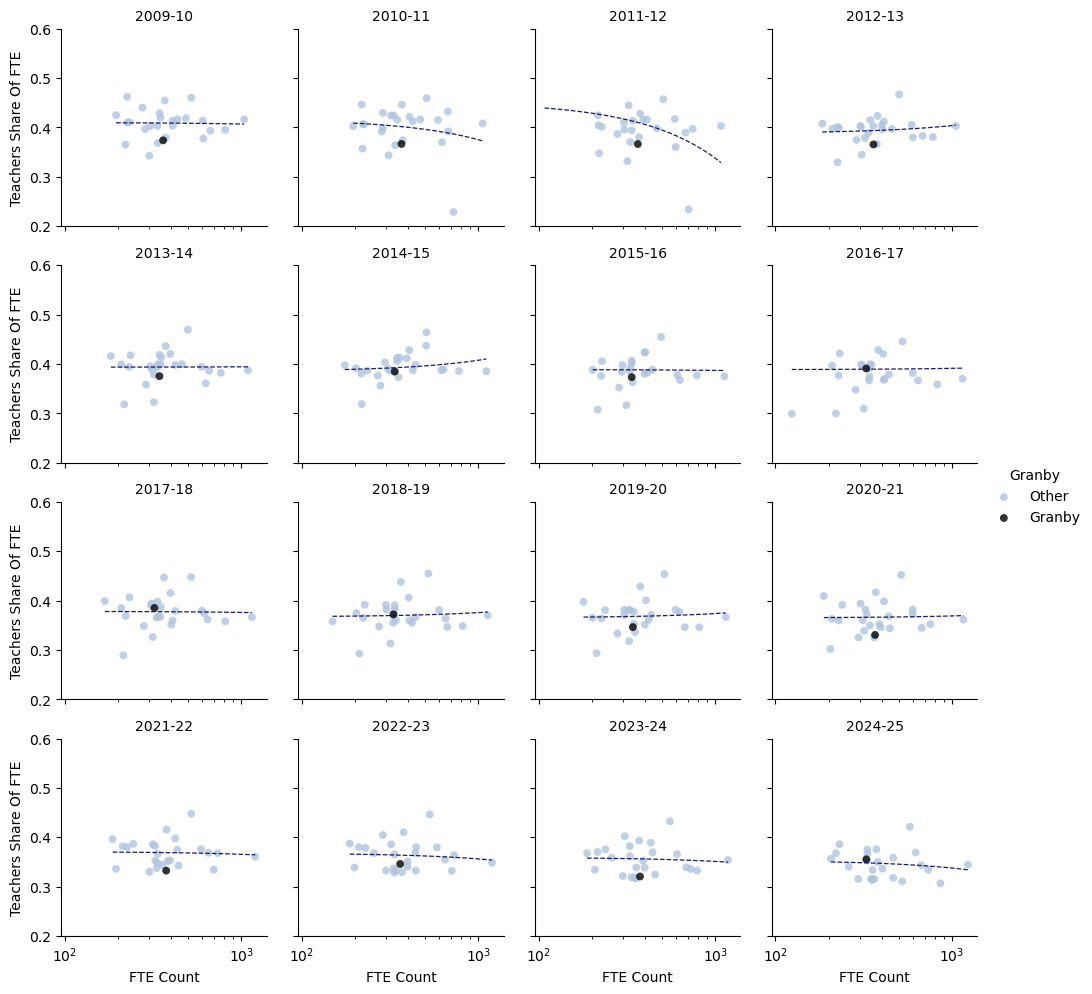

In [88]:
g = sns.lmplot(data=peerstaff,
               y='Teachers Share Of FTE', x='FTE Count',
               col='Year', col_wrap=4, hue='Granby', height=2.5, logx=False,
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], ci=None,
               scatter_kws={'s': 32, 'edgecolors': 'none'}, 
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})
g.set(ylim=(.2,.6))
g.set(xscale="log")
g.set_titles("{col_name}")
plt.show()
#style='Granby', size='Granby', alpha=.7, height=2.5, sizes=[9, 27],

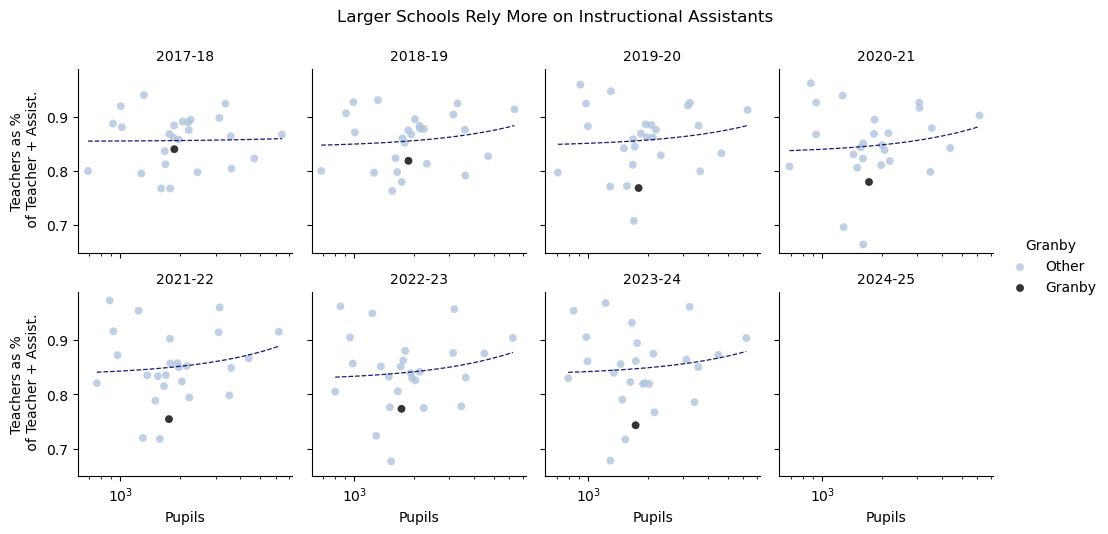

In [89]:
g = sns.lmplot(data=peerstaff[peerstaff['Year'] >= '2017'],
               y='Teachers Share of Educational', x='Pupils', ci=None,
               col='Year', col_wrap=4, hue='Granby', height=2.5, logx=False,
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], 
               scatter_kws={'s': 32, 'edgecolors': 'none'}, 
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})
g.set(xscale="log")
g.set_titles("{col_name}")
g.set_ylabels(label='Teachers as %\n of Teacher + Assist.')
g.figure.suptitle('Larger Schools Rely More on Instructional Assistants', y=1.05)
plt.show()
#style='Granby', size='Granby', alpha=.7, height=2.5, sizes=[9, 27],

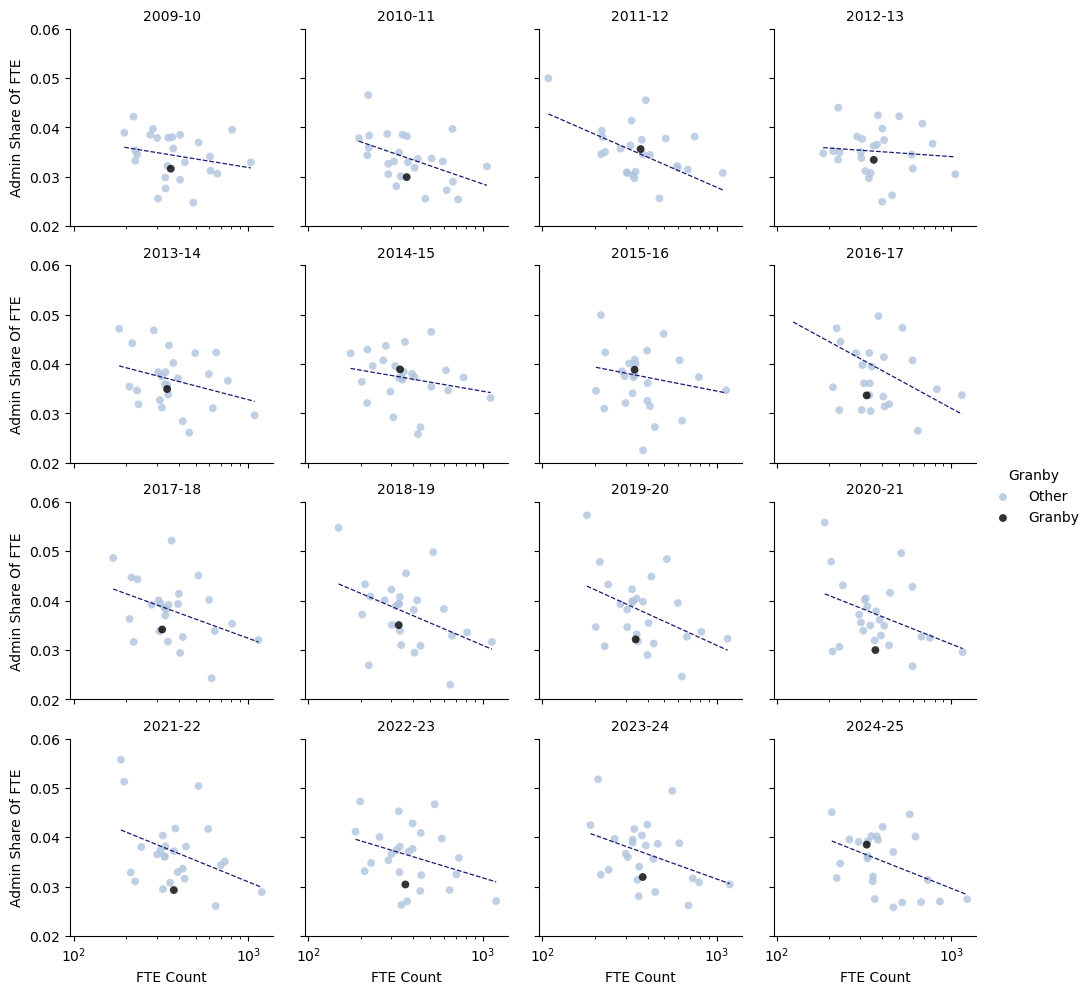

In [90]:
g = sns.lmplot(data=peerstaff,
               y='Admin Share Of FTE', x='FTE Count',
               col='Year', col_wrap=4, hue='Granby', height=2.5, logx=True,
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], ci = None,
               scatter_kws={'s': 32, 'edgecolors': 'none'}, 
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})
g.set(xscale="log")
g.set(ylim=(.02,.06))

g.set_titles("{col_name}")
plt.show()

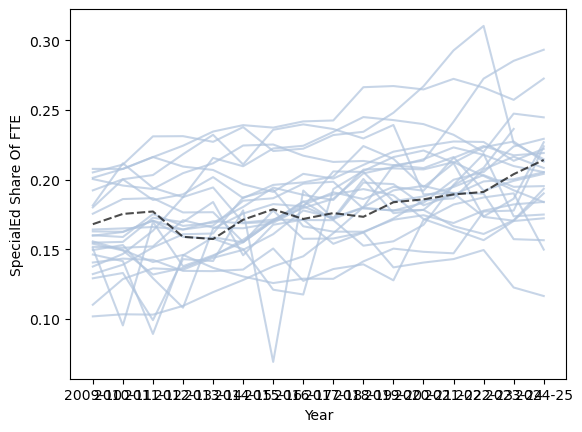

In [91]:
school_cols = {x:'lightsteelblue' for x in peerstaff.District.unique()}
school_cols = school_cols | {'Granby School District': 'black'}
g = sns.lineplot(data=peerstaff,
                y='SpecialEd Share Of FTE', x='Year', hue='District', legend=None,
                style='Granby', alpha=.7, sizes=[9, 27], palette=school_cols)
plt.show()

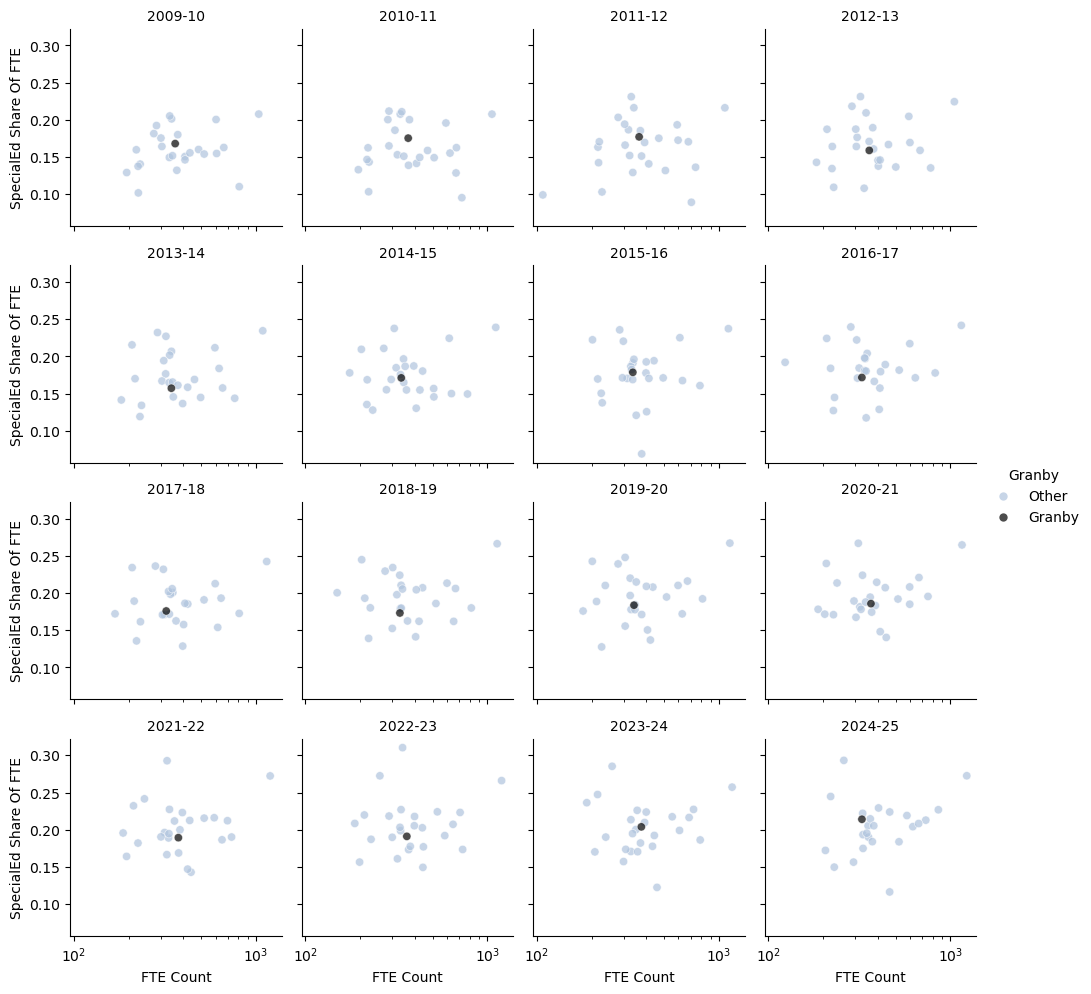

In [92]:
g = sns.relplot(data=peerstaff,
                y='SpecialEd Share Of FTE', x='FTE Count', col='Year', col_wrap=4, hue='Granby',
            style='Granby',  alpha=.7, height=2.5, sizes=[9, 27], markers=['o', 'o'], palette=['lightsteelblue', 'black'])
g.set(xscale="log")
g.set_titles("{col_name}")
plt.show()

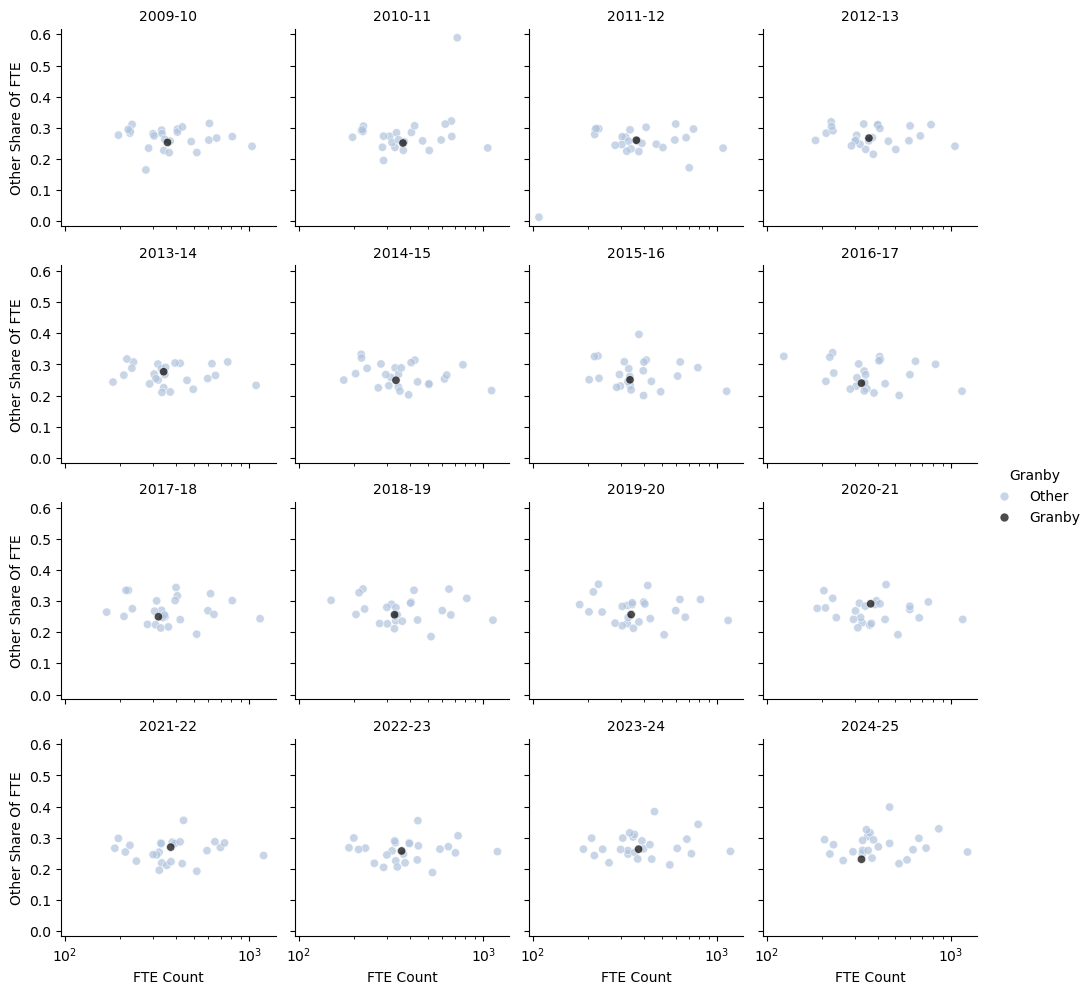

In [93]:
g = sns.relplot(data=peerstaff[peerstaff['FTE Count'] > 100],
                y='Other Share Of FTE', x='FTE Count', col='Year', col_wrap=4, hue='Granby',
            style='Granby',  alpha=.7, height=2.5, sizes=[9, 27], markers=['o', 'o'], palette=['lightsteelblue', 'black'])
g.set(xscale="log")

g.set_titles("{col_name}")
plt.show()

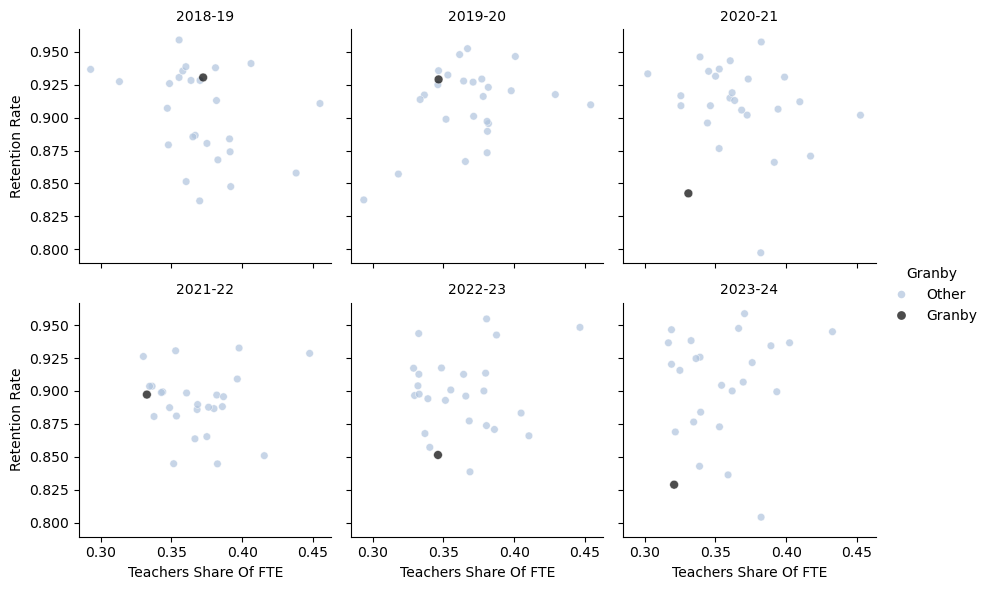

In [94]:
g = sns.relplot(data=peerstaff[(peerstaff['Year'] > '2018') & (peerstaff['Year'] < '2024')],
                x='Teachers Share Of FTE', y='Retention Rate', col='Year', col_wrap=3, hue='Granby',
            style='Granby', size='Granby', alpha=.7, height=3, sizes=[30, 40], markers=['o', 'o'], palette=['lightsteelblue', 'black'])

g.set_titles("{col_name}")
plt.show()

## Retention Data
It might be useful to look at the different types of exits: how many are still teaching and how many are not. That could be a way of marking retirement.

One thing here - the staff reduction may be intentional.

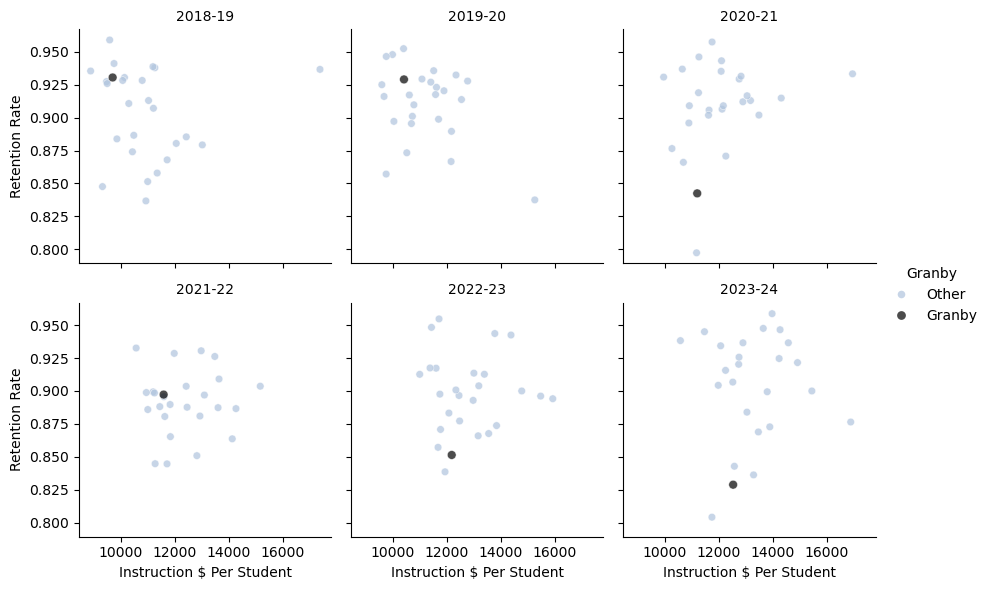

In [95]:
g = sns.relplot(data=peerstaff[(peerstaff['Year'] > '2018') & (peerstaff['Year'] < '2024')],
                x='Instruction $ Per Student', y='Retention Rate', col='Year', col_wrap=3, hue='Granby',
            style='Granby', size='Granby', alpha=.7, height=3, sizes=[30, 40], markers=['o', 'o'], palette=['lightsteelblue', 'black'])

g.set_titles("{col_name}")

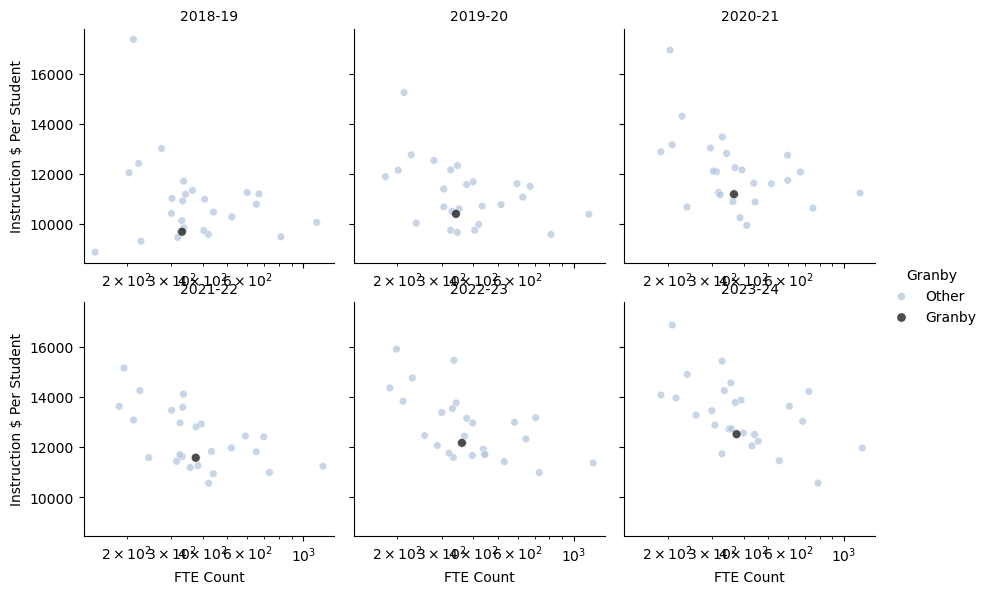

In [96]:
g = sns.relplot(data=peerstaff[(peerstaff['Year'] > '2018') & (peerstaff['Year'] < '2024')],
                y='Instruction $ Per Student', x='FTE Count', col='Year', col_wrap=3, hue='Granby',
            style='Granby', size='Granby', alpha=.7, height=3, sizes=[30, 40], markers=['o', 'o'], palette=['lightsteelblue', 'black'])
g.set(xscale="log")
g.set_titles("{col_name}")

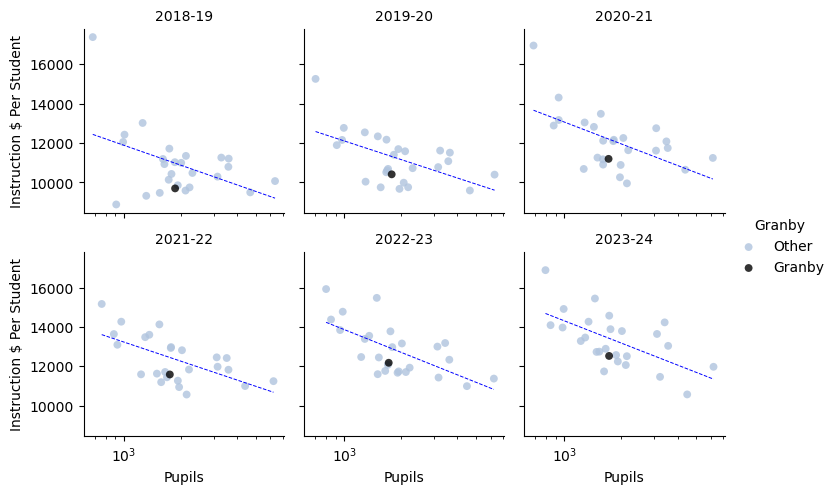

In [97]:
g = sns.lmplot(data=peerstaff[(peerstaff['Year'] > '2018') & (peerstaff['Year'] < '2024')],
               y='Instruction $ Per Student', x='Pupils',
               col='Year', col_wrap=3, hue='Granby', height=2.5, logx=True, ci=None,
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], scatter_kws={'s': [32], 'edgecolors':'none'},
               line_kws={'ls': '--', 'color': 'blue', 'lw': .7})
g.set(xscale="log")
g.set_titles("{col_name}")
#style='Granby', size='Granby', alpha=.7, height=3, sizes=[9, 27], markers=['o', 'o'], palette=['orange', 'blue']

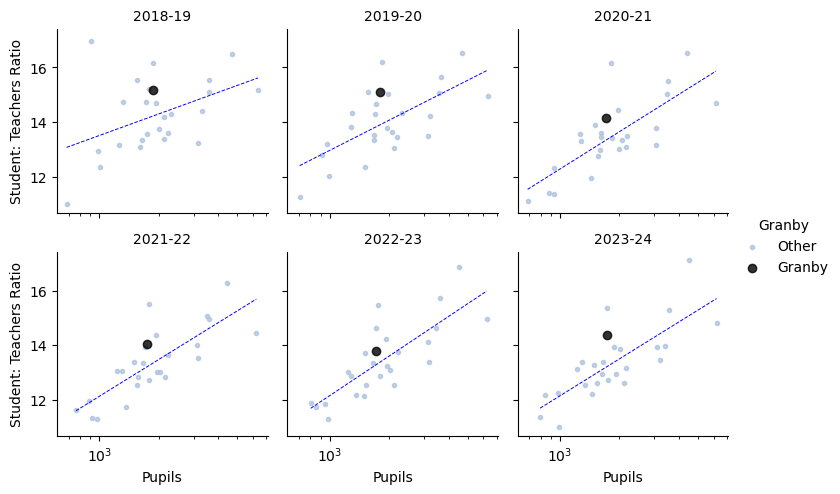

In [98]:
g = sns.lmplot(data=peerstaff[(peerstaff['Year'] > '2018') & (peerstaff['Year'] < '2024')],
               y='Student: Teachers Ratio', x='Pupils',
               col='Year', col_wrap=3, hue='Granby', height=2.5, logx=True, ci=None,
               markers=['.', 'o'], palette=['lightsteelblue', 'black'],
               line_kws={'ls': '--', 'color': 'blue', 'lw': .7})
g.set(xscale="log")
g.set_titles("{col_name}")
#style='Granby', size='Granby', alpha=.7, height=3, sizes=[9, 27], markers=['o', 'o'], palette=['orange', 'blue']

## Expenditures

In [99]:
def split_function(x):
    return x.replace(" - ", ":\n").title()

In [100]:
peer_expenditures = function_exp[(function_exp['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                                (function_exp['High Grade'] == 12) & (function_exp['JSG_ORIG'] == 6) &
                                (~function_exp['Function'].isin(['Minor school construction', 'Enterprise operations', 'Food services']))]

peer_expenditures.head()

,index,District,District Code_x,Function,Expenditures,Pupils,Pupil Basis,PPE,Year,Town,...,Pupil_Growth,PPE_Growth,Expenditures_Growth,Real_PPE_Growth,Real_Expenditures_Growth,Granby,Granby_EG,Granby_PPEG,Granby_Real_EG,Granby_Real_PPEG
2746,2142,Canton School District,023,Administration and Support Services,2852881.0,1748.0,NaN,1632.08,2012-13,Canton,...,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN
2747,2149,Canton School District,023,Administration and Support Services,2775050.0,1688.0,NaN,1643.99,2013-14,Canton,...,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN
2748,2156,Canton School District,023,Administration and Support Services,2745072.0,1619.0,NaN,1695.54,2014-15,Canton,...,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN
2749,2163,Canton School District,023,Administration and Support Services,3340478.0,1626.0,NaN,2054.41,2015-16,Canton,...,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN
2750,2170,Canton School District,023,Administration and Support Services,3362834.0,1616.0,NaN,2080.96,2016-17,Canton,...,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN


In [101]:
peer_expenditures = function_exp[(function_exp['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                                (function_exp['High Grade'] == 12) & (function_exp['JSG_ORIG'] == 6) &
                                (~function_exp['Function'].isin(['Minor school construction', 'Enterprise operations', 'Food services']))]

peer_ave = peer_expenditures.groupby(['Function', 'Year'])['PPE_Growth'].median().reset_index()\
           .rename(columns={'PPE_Growth': 'PPE Growth'})
peer_expenditures = peer_expenditures.merge(peer_ave, how='left', on=['Function', 'Year'])
peer_expenditures['School Year'] = peer_expenditures['Year'].str.slice(0,4)
peer_expenditures.sort_values(by=['School Year', 'Function', 'District'], inplace=True)

In [102]:
peer_expenditures[['Low Grade', 'Organization Type']].value_counts()

Low Grade  Organization Type        
PreK       Public School Districts      1862
           Regional School Districts     686
Name: count, dtype: int64

In [103]:
peer_expenditures[peer_expenditures['Low Grade'] != 'PreK']['District'].value_counts()

Series([], Name: count, dtype: int64)

In [104]:
peer_expenditures[peer_expenditures['Function'] == 'Instruction'].groupby('District')['PPE_Growth'].mean().sort_values()

District
Regional School District 18       0.976584
Lebanon School District           0.976745
North Haven School District       0.995685
Suffield School District          1.027268
Wethersfield School District      1.029487
East Haddam School District       1.039196
East Hampton School District      1.039256
Regional School District 12       1.042361
Oxford School District            1.043339
Southington School District       1.043361
Regional School District 15       1.045658
Regional School District 17       1.049125
Wolcott School District           1.051562
Colchester School District        1.058102
Coventry School District          1.061042
Guilford School District          1.074872
Cromwell School District          1.076148
Granby School District            1.078019
Shelton School District           1.087201
Canton School District            1.099877
Regional School District 16       1.100457
North Branford School District    1.104812
Portland School District          1.112007
Cl

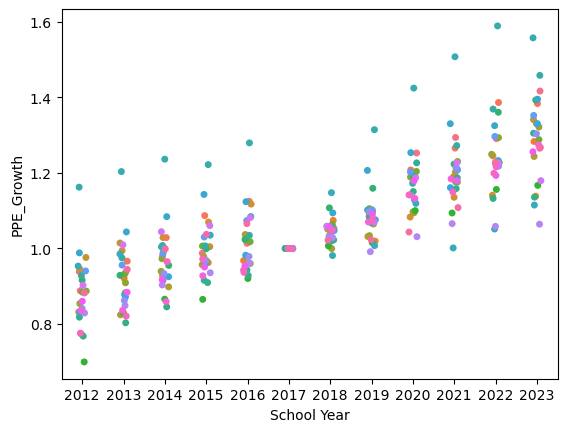

In [105]:
g = sns.stripplot(data=peer_expenditures[peer_expenditures['Function'] == 'Instruction'],
                y='PPE_Growth', x='School Year', hue='District', legend=False)


#g.map_dataframe(sns.scatterplot, x='School Year', y='Granby_PPEG', color='black', zorder=10)
#g.map_dataframe(sns.lineplot, x='School Year', y='PPE Growth', color='black', lw=.7, ls="--", zorder=5)
#g.set_titles("{col_name}")
#g.set_xlabels(label=None)


plt.show()

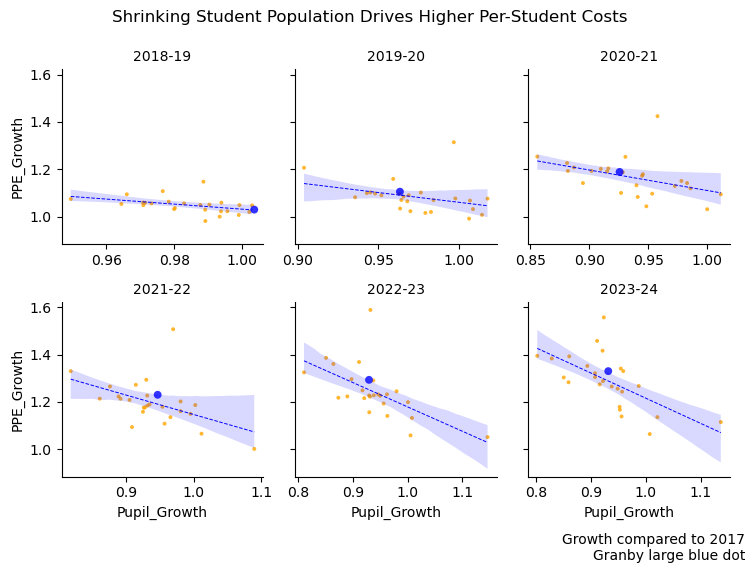

In [106]:
g = sns.lmplot(data=peer_expenditures[(peer_expenditures['Function'] == 'Instruction') & (peer_expenditures['Year'] > '2017-18')],
               y='PPE_Growth', x='Pupil_Growth',
               col='Year', col_wrap=3, hue='Granby', height=2.5, logx=False, legend=False,
               markers=['.', 'o'], palette=['orange', 'blue'], 
               scatter_kws={'s': [32], 'edgecolors':'none'},
               facet_kws={'sharex':False},
               line_kws={'ls': '--', 'color': 'blue', 'lw': .7})
#g.set(xscale="log")
g.set_titles("{col_name}")
g.fig.suptitle("Shrinking Student Population Drives Higher Per-Student Costs", y=1.05)
g.fig.text(x=1, y=-.05, s="Growth compared to 2017\nGranby large blue dot", ha='right')
#style='Granby', size='Granby', alpha=.7, height=3, sizes=[9, 27], markers=['o', 'o'], palette=['orange', 'blue']
plt.show()

/var/folders/86/cc1s6rr57cl3q5tchh66wtzc0000gr/T/ipykernel_9954/1248910658.py:3: UserWarning: 
The palette list has fewer values (1) than needed (20) and will cycle, which may produce an uninterpretable plot.
  g = sns.catplot(data=peer_expenditures[~peer_expenditures['Function'].str.startswith('Administration')],


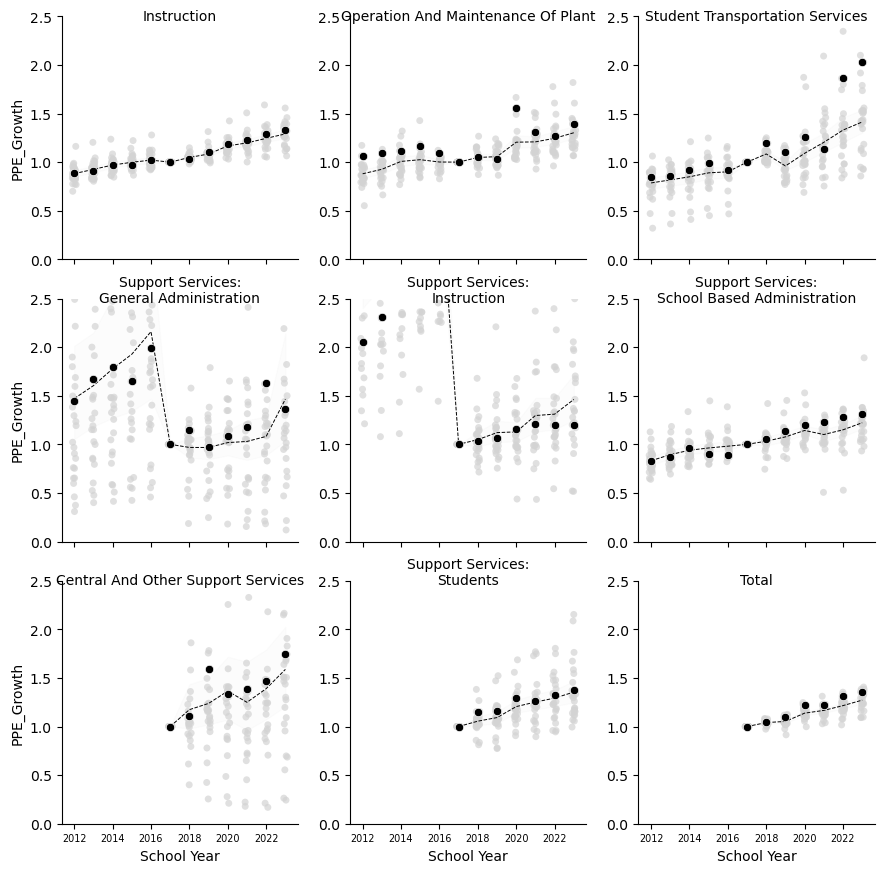

In [107]:
# BECAUSE OVERLAY ONTO CATPLOT X-AXIS NEEDS TO BE STRING

g = sns.catplot(data=peer_expenditures[~peer_expenditures['Function'].str.startswith('Administration')],
                 x='School Year', y='PPE_Growth', hue='Town', kind='strip',
                col='Function', col_wrap=3, legend=False, sharey=False,
                alpha=.7, height=3, palette=['lightgray'])
g.map_dataframe(sns.scatterplot, x='School Year', y='Granby_PPEG', color='black', zorder=10)
g.map_dataframe(sns.lineplot, x='School Year', y='PPE_Growth', estimator='mean', color='black', err_kws={'alpha':.01}, lw=.7, ls="--", zorder=5)
g.set_titles("{col_name}")
g.tick_params(axis='x', labelsize='x-small')
g.set(ylim=(0,2.5))
doit=0
for ax in g.axes.flat:
    # Get the current title text
    current_title = ax.get_title()
    # Apply the function and set the new title
    ax.set_title(split_function(current_title), fontsize=10, y=.95)
    xt = ax.get_xticks()
    if (len(xt) > 1) & (doit==0):
       doit=1
       ax.set_xticks(ticks=xt[::2])

plt.show()

/var/folders/86/cc1s6rr57cl3q5tchh66wtzc0000gr/T/ipykernel_9954/2559235743.py:4: UserWarning: 
The palette list has fewer values (1) than needed (20) and will cycle, which may produce an uninterpretable plot.
  g = sns.catplot(data=peer_expenditures[(~peer_expenditures['Function'].str.startswith('Administration'))


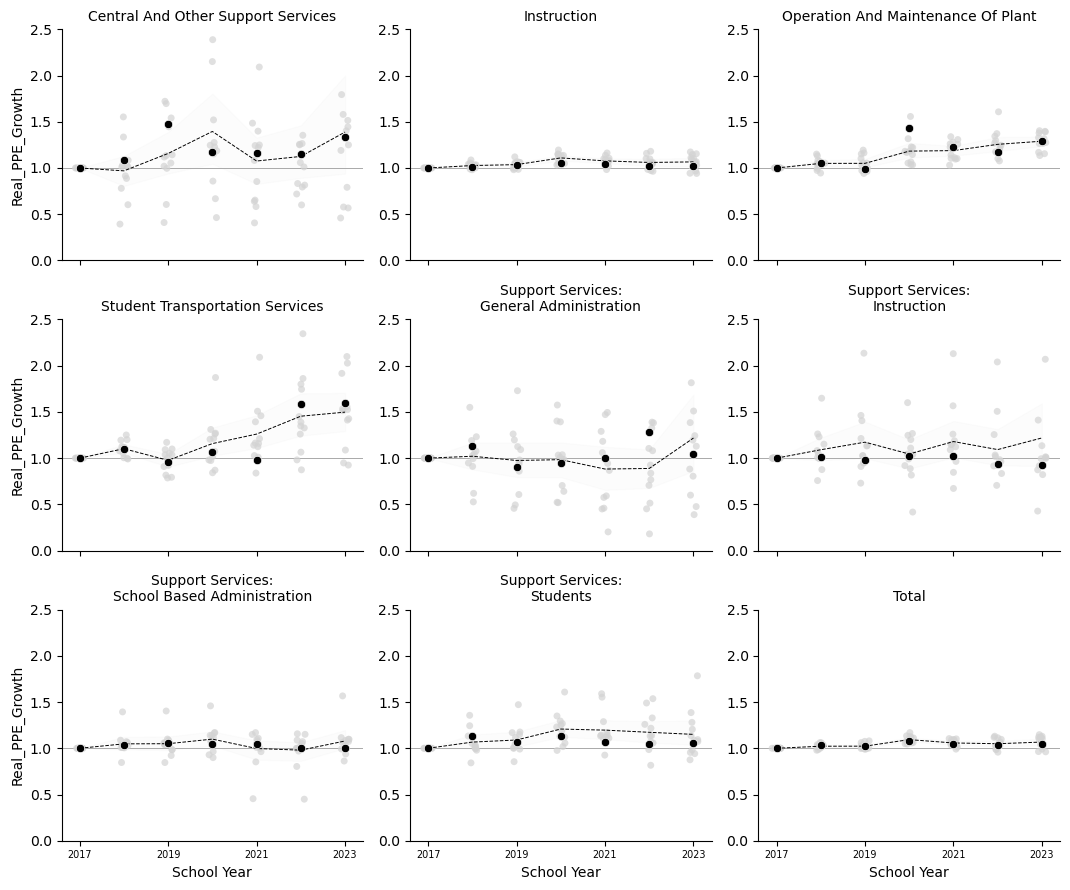

In [108]:
# BECAUSE OVERLAY ONTO CATPLOT X-AXIS NEEDS TO BE STRING


g = sns.catplot(data=peer_expenditures[(~peer_expenditures['Function'].str.startswith('Administration'))
                  & (peer_expenditures['School Year'] > '2016')],
                 x='School Year', y='Real_PPE_Growth', hue='Town', kind='strip',
                col='Function', col_wrap=3, legend=False, sharey=False,
                alpha=.7, height=3, aspect=1.2, palette=['lightgray'])
g.map_dataframe(sns.scatterplot, x='School Year', y='Granby_Real_EG', color='black', zorder=10)
g.map_dataframe(sns.lineplot, x='School Year', y='Real_PPE_Growth', estimator='mean', color='black', err_kws={'alpha':.01}, lw=.7, ls="--", zorder=5)
g.set_titles("{col_name}")
g.tick_params(axis='x', labelsize='x-small')
g.set(ylim=(0,2.5))
doit=0

for ax in g.axes.flat:
    # Get the current title text
    current_title = ax.get_title()
    # Apply the function and set the new title
    ax.axhline(y=1, c='darkgray', ls='-', lw=.7)
    ax.set_title(split_function(current_title), fontsize=10, y=1)
    xt = ax.get_xticks()
    if (len(xt) > 1) & (doit==0):
       doit=1
       ax.set_xticks(ticks=xt[::2])
plt.tight_layout()
plt.show()

## Accountability Index

### NO COVID YEARS!

Granby does not have Progress Toward English Proficiency (ESL)

In [109]:
accountability = accountability.merge(school_types, how='left', on='District')

peer_accountability = accountability[(accountability['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                                (accountability['High Grade'] == 12) & (accountability['JSG_ORIG'] == 6)].copy()

peer_accountability.sort_values(by=['Granby', 'Year'], ascending=[False, True], inplace=True)
peer_accountability['School Year'] = peer_accountability['Year'].str.slice(0,4).astype('int')
peer_accountability.head()

,Year,AccountabilityIndex,District,School,ELA PI,ELA PI - High Needs,Math PI,Math PI - High Needs,Science PI,Science PI - High Needs,...,elite,urban,pca,affordable,finproj,JSG_ORIG,JSG_AUG,JSG_AFF,JSG_PCA10,School Year
207,2014-15,80.774502,Canton School District,District-level,100.000000,82.217138,92.134459,69.684853,87.207007,71.326577,...,0.0,0.0,0.0,0.0,0.0,6.0,3.0,7.0,5.0,2014
251,2014-15,85.504614,Clinton School District,District-level,98.756325,83.328072,86.901686,71.757819,82.535334,71.136928,...,0.0,0.0,0.0,0.0,0.0,6.0,3.0,3.0,5.0,2014
260,2014-15,84.073055,Colchester School District,District-level,100.000000,83.523775,88.703997,73.660652,85.023496,71.188272,...,0.0,0.0,1.0,1.0,1.0,6.0,6.0,5.0,3.0,2014
305,2014-15,82.864651,Coventry School District,District-level,96.887653,81.818104,84.354625,70.357156,85.033634,74.040936,...,0.0,0.0,0.0,1.0,0.0,6.0,3.0,5.0,5.0,2014
314,2014-15,83.813263,Cromwell School District,District-level,97.127905,80.043677,83.125701,65.108501,78.306315,67.509804,...,0.0,0.0,0.0,1.0,0.0,6.0,1.0,5.0,5.0,2014


In [110]:
peer_accountability.columns

Index(['Year', 'AccountabilityIndex', 'District', 'School', 'ELA PI',
       'ELA PI - High Needs', 'Math PI', 'Math PI - High Needs', 'Science PI',
       'Science PI - High Needs', 'ELA Growth', 'ELA Growth - High Needs',
       'Math Growth', 'Math Growth - High Needs',
       'Progress Toward English Proficiency - Literacy',
       'Progress Toward English Proficiency - Oral', 'Chronic Absenteeism',
       'Chronic Absenteeism - High Needs', 'CCR - Taking Courses',
       'CCR - Passing Exams', 'On-track to HS Graduation', '4-yr Graduation',
       '6-yr Graduation - High Needs', 'Postsecondary Entrance',
       'Physical Fitness', 'Arts Access', 'Town', 'Type', 'Granby', 'Code',
       'District Code', 'Low Grade', 'High Grade', 'Organization Type', 'DRG',
       'peer', 'augmented', 'elite', 'urban', 'pca', 'affordable', 'finproj',
       'JSG_ORIG', 'JSG_AUG', 'JSG_AFF', 'JSG_PCA10', 'School Year'],
      dtype='object')

In [111]:
values = ['Math PI', 'Math Growth', 'ELA PI', 'ELA Growth', 'Science PI',
          'CCR - Taking Courses', 'CCR - Passing Exams', 'Postsecondary Entrance', 
          'On-track to HS Graduation', '4-yr Graduation', 'Chronic Absenteeism',
           'Physical Fitness', 'Arts Access', 'AccountabilityIndex']

high_need = ['ELA PI - High Needs',  'ELA Growth - High Needs', 
             'Math PI - High Needs', 'Math Growth - High Needs',
             'Science PI - High Needs', 'Chronic Absenteeism - High Needs', '6-yr Graduation - High Needs']

peer_long = pd.melt(peer_accountability,
                        id_vars=['School Year', 'District', 'Granby'],
                        value_vars=values,
                        var_name='metric', value_name='value', col_level=None, ignore_index=True)

high_long = pd.melt(peer_accountability,
                        id_vars=['School Year', 'District', 'Granby'],
                        value_vars=high_need,
                        var_name='metric', value_name='value', col_level=None, ignore_index=True)

Connecticut's Next Generation Accountability reports for 2017-18 didn't show science scores because the state administered a field test (Smarter Science Field Test) instead of the regular CMT/CAPT science tests. 

In 2017-18, Connecticut's Next Generation Accountability system integrated Smarter Balanced tests (ELA/Math) with the new Next Generation Science Standards (NGSS) assessment, a field test/pilot for Grades 5, 8, and 11, aligning science with modern standards and transitioning from older science measures to a more comprehensive, standards-based approach for college/career readiness. Schools used multiple indicators, including these assessments, to show progress. 

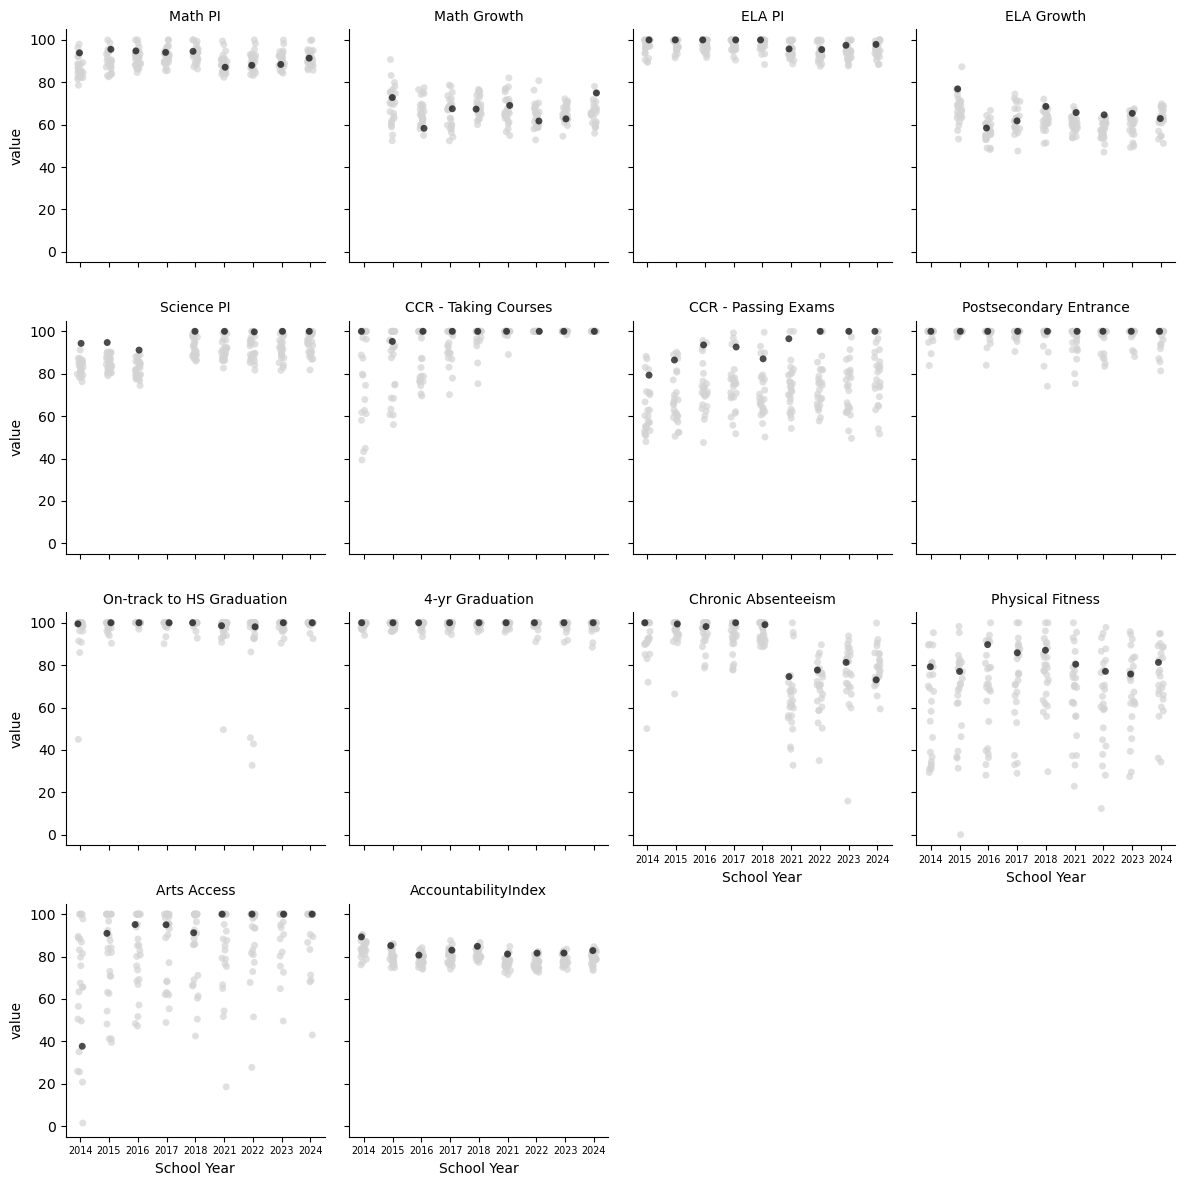

In [112]:
g = sns.catplot(data=peer_long,
                y='value', x='School Year', hue='Granby', kind='strip',
                col='metric', col_wrap=4, legend=False,
                alpha=.7, height=3, palette=['lightgray', 'black'])

g.set_titles("{col_name}")
g.tick_params(axis='x', labelsize='x-small')
plt.show()

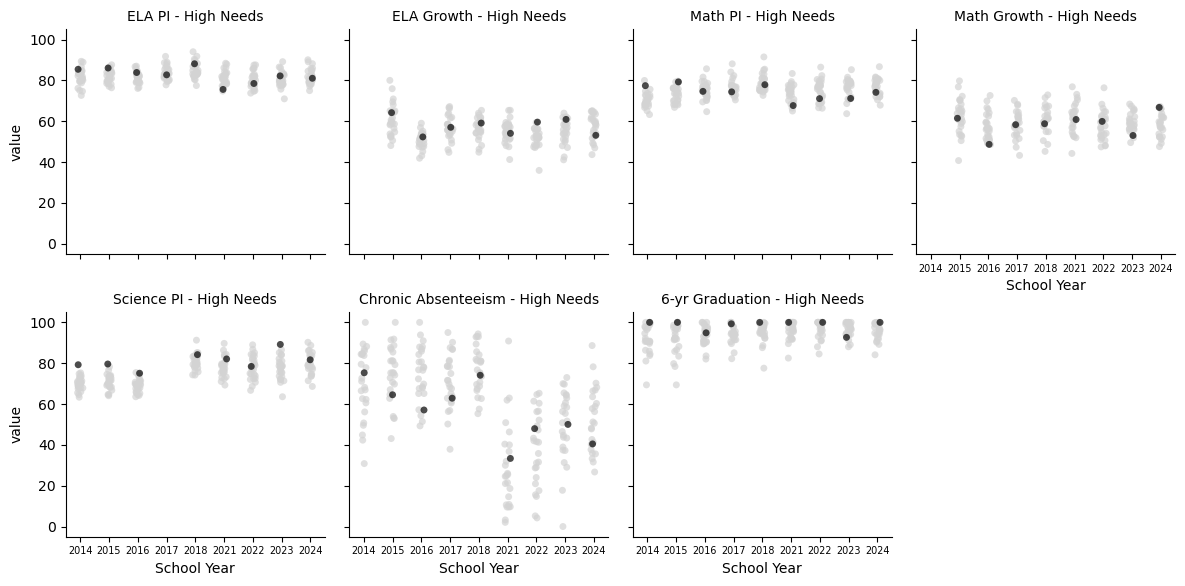

In [113]:
g = sns.catplot(data=high_long,
                y='value', x='School Year', hue='Granby', kind='strip',
                col='metric', col_wrap=4, legend=False,
                alpha=.7, height=3, palette=['lightgray', 'black'])

g.set_titles("{col_name}")
g.tick_params(axis='x', labelsize='x-small')
plt.show()

### Add performance to expenditures

In [114]:
#PPE should be the same as Instruction $ Per Student
peer_instruction = peer_expenditures[peer_expenditures['Function'] == 'Instruction'].merge(peer_accountability[['Year', 'District'] + values], how='left', on=['Year', 'District'])\
                                 .merge(peerstaff.drop(columns=['Town', 'Low Grade', 'High Grade','Organization Type', 'Type', 'Granby', 'Pupils', 'Size']),
                                            how='left', on=['Year', 'District'])

peer_combined = peer_expenditures[peer_expenditures['Function'] == 'Total'].merge(peer_accountability[['Year', 'District'] + values], how='left', on=['Year', 'District'])\
                                 .merge(peerstaff.drop(columns=['Town', 'Low Grade', 'High Grade','Organization Type', 'Type', 'Granby', 'Pupils', 'Size']),
                                            how='left', on=['Year', 'District'])

In [115]:
peer_instruction.sort_values(by=['District', 'Year'], inplace=True)
peer_instruction.reset_index(inplace=True, drop=True)

In [116]:
# calculate % change from prior year
changecols = ['Pupils', 'PPE', 'Instruction $', 'Instruction $ Per Student', 'Teachers', 'Educational', 'Student: Teachers Ratio', 'AccountabilityIndex']
changes = peer_instruction.groupby('District')[changecols].diff()/peer_instruction.groupby('District')[changecols].shift()
changes = changes.join(peer_instruction[['District', 'Year', 'Town', 'Type', 'Granby']].rename(columns={'Pupils': 'Students'}), how='inner')
changes

,Pupils,PPE,Instruction $,Instruction $ Per Student,Teachers,Educational,Student: Teachers Ratio,AccountabilityIndex,District,Year,Town,Type,Granby
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Canton School District,2012-13,Canton,Town,Other
1,-0.034338,0.056061,0.019798,0.056061,-0.028249,-0.017329,NaN,NaN,Canton School District,2013-14,Canton,Town,Other
2,-0.040695,0.044719,0.002203,0.044719,-0.035853,-0.094048,NaN,NaN,Canton School District,2014-15,Canton,Town,Other
3,0.004119,0.007793,0.011943,0.007793,-0.001005,0.068127,NaN,0.036638,Canton School District,2015-16,Canton,Town,Other
4,-0.005332,0.026305,0.020833,0.026305,-0.016097,-0.009871,NaN,-0.045250,Canton School District,2016-17,Canton,Town,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,-0.024096,0.000718,-0.023321,0.000718,-0.008537,-0.006959,-0.011273,NaN,Wolcott School District,2019-20,Wolcott,Town,Other
308,-0.022137,0.020195,-0.002403,0.020195,0.010455,0.017790,-0.027082,NaN,Wolcott School District,2020-21,Wolcott,Town,Other
309,0.009142,0.061897,0.071534,0.061897,0.021302,0.042373,-0.019948,NaN,Wolcott School District,2021-22,Wolcott,Town,Other
310,-0.019845,0.108062,0.086089,0.108062,0.009535,0.022358,-0.020947,-0.048535,Wolcott School District,2022-23,Wolcott,Town,Other


In [117]:
changes[changes['Instruction $ Per Student'] > .2]

,Pupils,PPE,Instruction $,Instruction $ Per Student,Teachers,Educational,Student: Teachers Ratio,AccountabilityIndex,District,Year,Town,Type,Granby
175,0.00765,0.339151,0.349462,0.339151,0.333955,0.260575,-0.247054,NaN,Regional School District 06,2019-20,Regional,Regional,Other


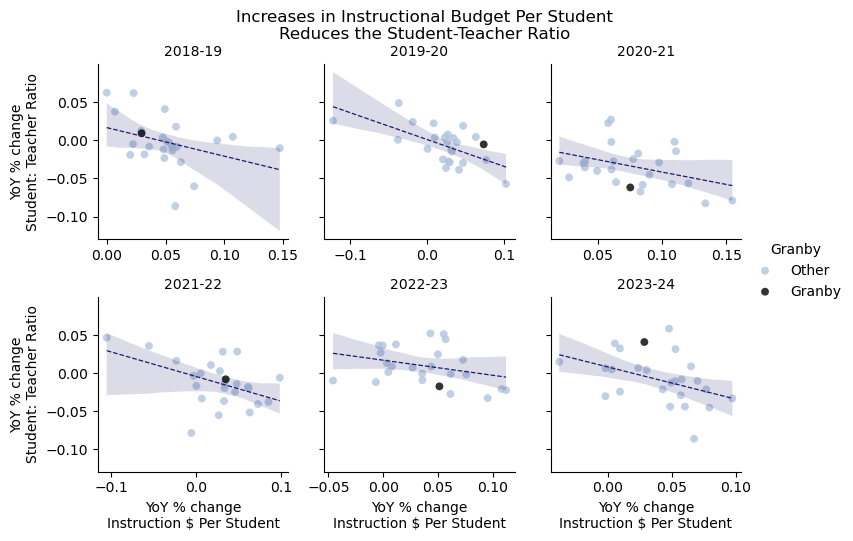

In [118]:
g = sns.lmplot(data=changes[(~changes['District'].isin(('Regional School District 06',
                                                       'Danbury School District', 
                                                       'Greenwich School District')))
                            & (changes['Year'] > '2017-18')],
               y='Student: Teachers Ratio', x='Instruction $ Per Student',
               col='Year', col_wrap=3, hue='Granby', height=2.5, 
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], 
               scatter_kws={'s': 32, 'edgecolors': 'none'}, facet_kws={'sharex':False},
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})
g.fig.suptitle("Increases in Instructional Budget Per Student\nReduces the Student-Teacher Ratio", y=1.04)
g.set_titles("{col_name}")
g.set_ylabels("YoY % change\nStudent: Teacher Ratio")
g.set_xlabels("YoY % change\nInstruction $ Per Student")
plt.show()

In [119]:
peer_combined.columns

Index(['index', 'District', 'District Code_x_x', 'Function', 'Expenditures',
       'Pupils', 'Pupil Basis', 'PPE', 'Year', 'Town',
       ...
       'Admin Share Of FTE', 'Admin Per Student', 'Student: Admin Ratio',
       'Counselors Share Of FTE', 'Counselors Per Student',
       'Student: Counselors Ratio', 'SpecialEd Share Of FTE',
       'SpecialEd Per Student', 'Student: SpecialEd Ratio',
       'Teachers Share of Educational'],
      dtype='object', length=129)

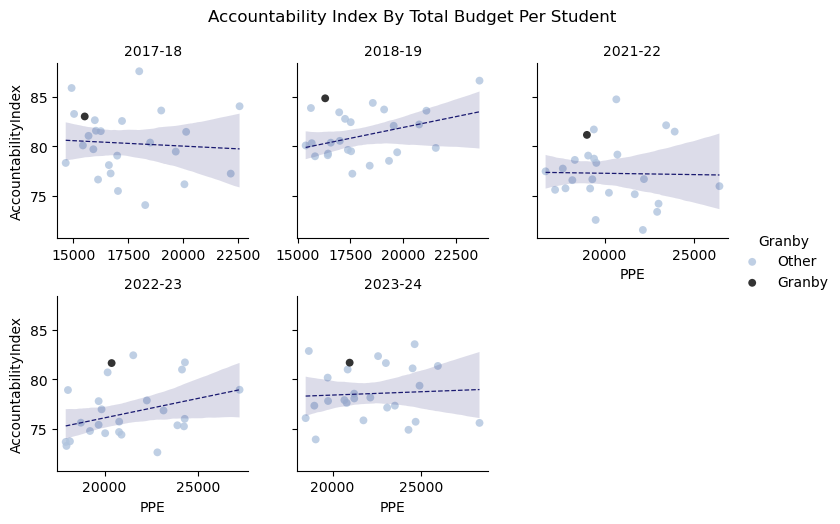

In [133]:
g = sns.lmplot(data=peer_combined[(~peer_combined['School Year'].isin(('2019','2020'))) & (peer_combined['District'] != 'Regional School District 12')],
               y='AccountabilityIndex', x='PPE', 
               col='Year', col_wrap=3, hue='Granby', height=2.5, logx=False,
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], 
               scatter_kws={'s': 32, 'edgecolors': 'none'}, 
               facet_kws={'sharex':False},
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})
g.fig.suptitle("Accountability Index By Total Budget Per Student", y=1.04)
g.set_titles("{col_name}")
plt.show()

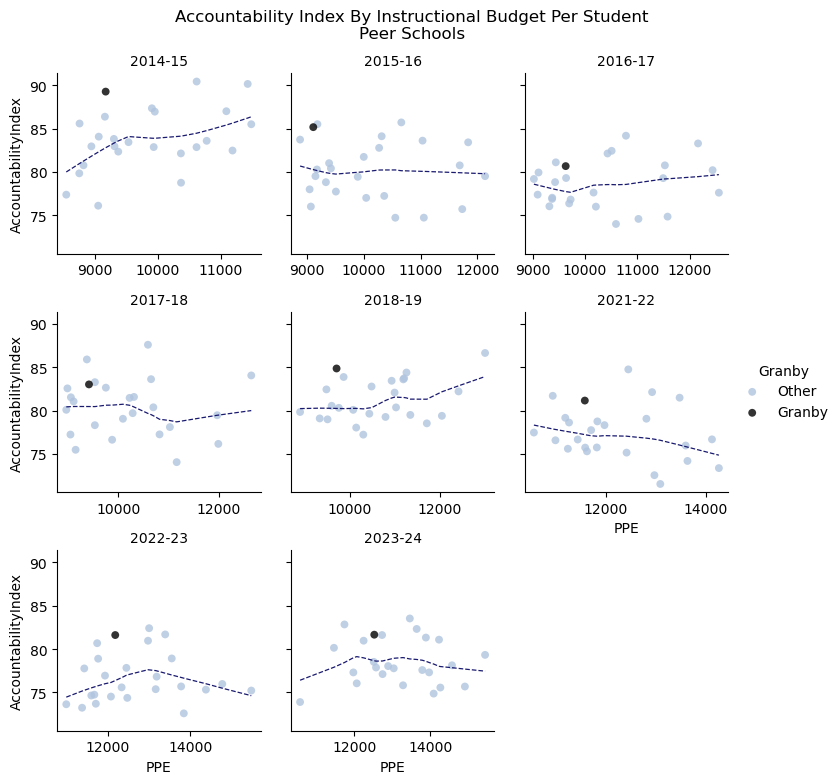

In [131]:
g = sns.lmplot(data=peer_instruction[(~peer_instruction['School Year'].isin(('2012', '2013', '2019','2020'))) & (peer_instruction['District'] != 'Regional School District 12')],
               y='AccountabilityIndex', x='PPE', lowess=True,
               col='Year', col_wrap=3, hue='Granby', height=2.5, logx=False,
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], 
               scatter_kws={'s': 32, 'edgecolors': 'none'},
               facet_kws={'sharex':False},
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})
#g.set(xscale="log")
g.fig.suptitle("Accountability Index By Instructional Budget Per Student\nPeer Schools", y=1.04)
g.set_titles("{col_name}")
plt.show()

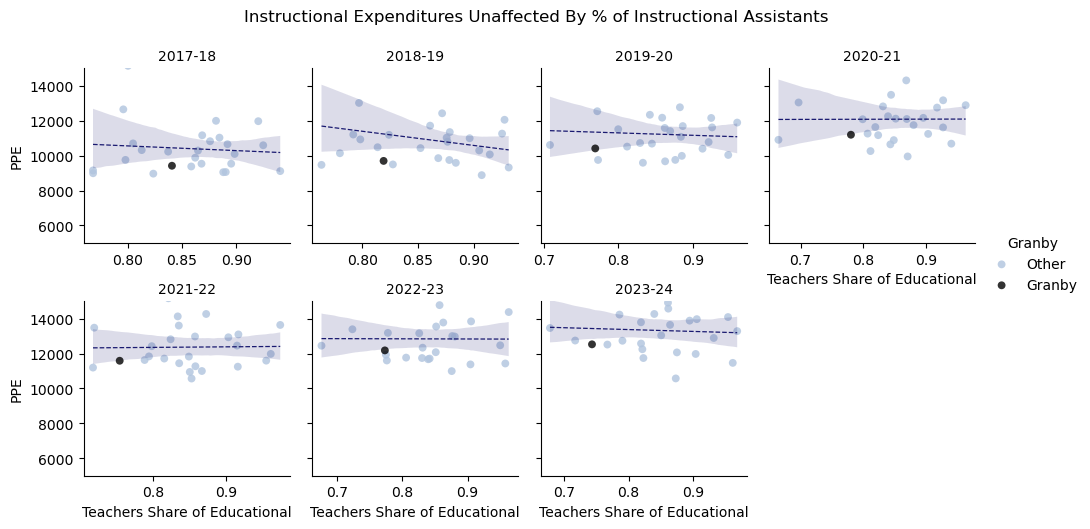

In [134]:
g = sns.lmplot(data=peer_instruction[peer_instruction['Year'] >= '2017'],
                y='PPE', x='Teachers Share of Educational', 
               col='Year', col_wrap=4, hue='Granby', height=2.5, logx=False,
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], 
               scatter_kws={'s': 32, 'edgecolors': 'none'},
               facet_kws={'sharex':False},
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})
#g.set(xscale="log")
g.set_titles("{col_name}")

g.set(ylim=(5000, 15000))
g.figure.suptitle('Instructional Expenditures Unaffected By % of Instructional Assistants', y=1.05)
plt.show()
#style='Granby', size='Granby', alpha=.7, height=2.5, sizes=[9, 27],

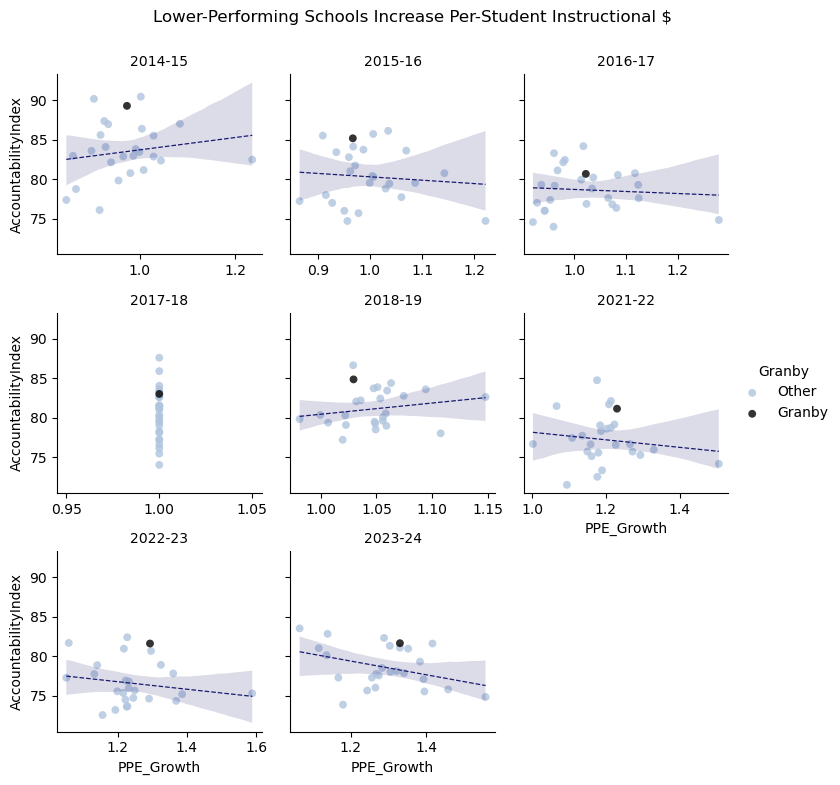

In [123]:
g = sns.lmplot(data=peer_instruction[(~peer_instruction['School Year'].isin(('2012', '2013', '2019','2020')))],
               y='AccountabilityIndex', x='PPE_Growth',
               col='Year', col_wrap=3, hue='Granby', height=2.5, logx=False,
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], 
               scatter_kws={'s': 32, 'edgecolors': 'none'}, facet_kws={'sharex':False},
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})
#g.set(xscale="log")
g.fig.suptitle("Lower-Performing Schools Increase Per-Student Instructional $", y=1.04)
g.set_titles("{col_name}")
plt.show()

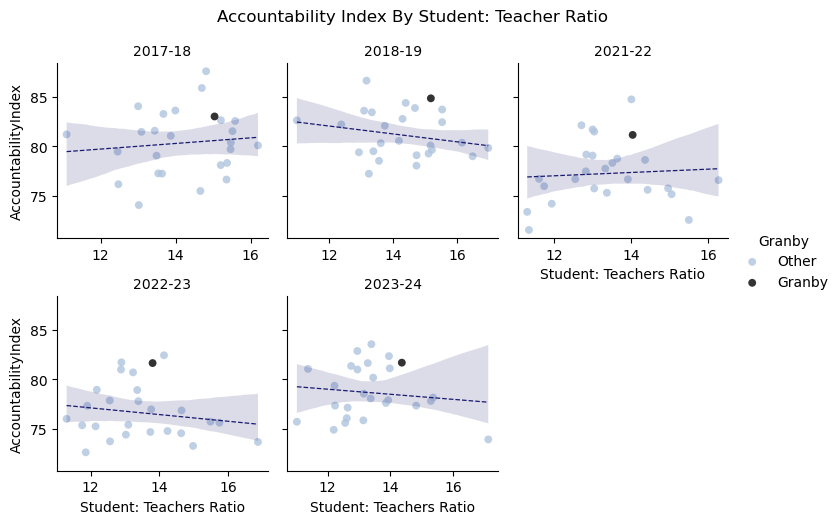

In [124]:
g = sns.lmplot(data=peer_combined[(~peer_combined['School Year'].isin(('2012', '2013', '2019','2020')))],
               y='AccountabilityIndex', x='Student: Teachers Ratio',
               col='Year', col_wrap=3, hue='Granby', height=2.5, logx=False,
               markers=['o', 'o'], palette=['lightsteelblue', 'black'], 
               scatter_kws={'s': 32, 'edgecolors': 'none'}, 
               facet_kws={'sharex':False},
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})
#g.set(xscale="log")
g.fig.suptitle("Accountability Index By Student: Teacher Ratio", y=1.04)
g.set_titles("{col_name}")
plt.show()

In [125]:

    Index(['District', 'District Code', 'Function', 'Expenditures', 'Pupils',
       'Pupil Basis', 'PPE', 'Year', 'Town', 'Type', 'Expenditures_2017',
       'PPE_2017', 'Expenditures_2018', 'PPE_2018', 'Low Grade', 'High Grade',
       'Organization Type', 'PPE_Base', 'Expenditures_Base', 'PPE_Growth',
       'Expenditures_Growth', 'Granby', 'Granby_EG', 'Granby_PPEG',
       'PPE Growth', 'School Year', 'Math PI', 'Math Growth', 'ELA PI',
       'ELA Growth', 'Science PI', 'CCR - Taking Courses',
       'CCR - Passing Exams', 'Postsecondary Entrance',
       'On-track to HS Graduation', '4-yr Graduation', 'Chronic Absenteeism',
       'Physical Fitness', 'Arts Access', 'AccountabilityIndex', 'FTE Count',
       'Teachers', 'Other', 'Admin', 'Counselors', 'SpecialEd', 'Payroll',
       'Payroll Per Student', 'Instruction $', 'Instruction $ Per Student',
       'Retention', 'Classroom Teachers', 'Retention Rate',
       'Teachers Share Of FTE', 'Teachers Per Student',
       'Student: Teachers Ratio', 'Other Share Of FTE', 'Other Per Student',
       'Student: Other Ratio', 'Admin Share Of FTE', 'Admin Per Student',
       'Student: Admin Ratio', 'Counselors Share Of FTE',
       'Counselors Per Student', 'Student: Counselors Ratio',
       'SpecialEd Share Of FTE', 'SpecialEd Per Student',
       'Student: SpecialEd Ratio']

SyntaxError: incomplete input (1341695925.py, line 20)

In [ ]:
peer_instruction[(peer_instruction['Function'] == 'Instruction')
                & (peer_instruction['School Year'] >= '2018')
                & (peer_instruction['PPE_Growth'] > 1.4)]\
            [['District', 'Year', 'AccountabilityIndex', 'Pupils', 'PPE',  'PPE_Growth', 'Pupil_Growth',
            'Student: Teachers Ratio', 'SpecialEd Share Of FTE','Classroom Teachers', 'Retention Rate']].sort_values(by=['District', 'Year'])


In [ ]:
peer_instruction[(peer_instruction['Function'] == 'Instruction')
                & (peer_instruction['School Year'] >= '2018')
                & (peer_instruction['Town'] =='Granby')]\
            [['District', 'Year', 'AccountabilityIndex', 'Pupils', 'PPE',  'PPE_Growth',
            'Student: Teachers Ratio', 'SpecialEd Share Of FTE','Classroom Teachers', 'Retention Rate']].sort_values(by=['District', 'Year'])


In [ ]:
staffing.groupby(['Assignment Category'])['FTE Count'].mean().sort_values()

In [ ]:
with pd.option_context('display.max_rows', None):
    display(staffing[['Town', 'District']].value_counts().sort_index())